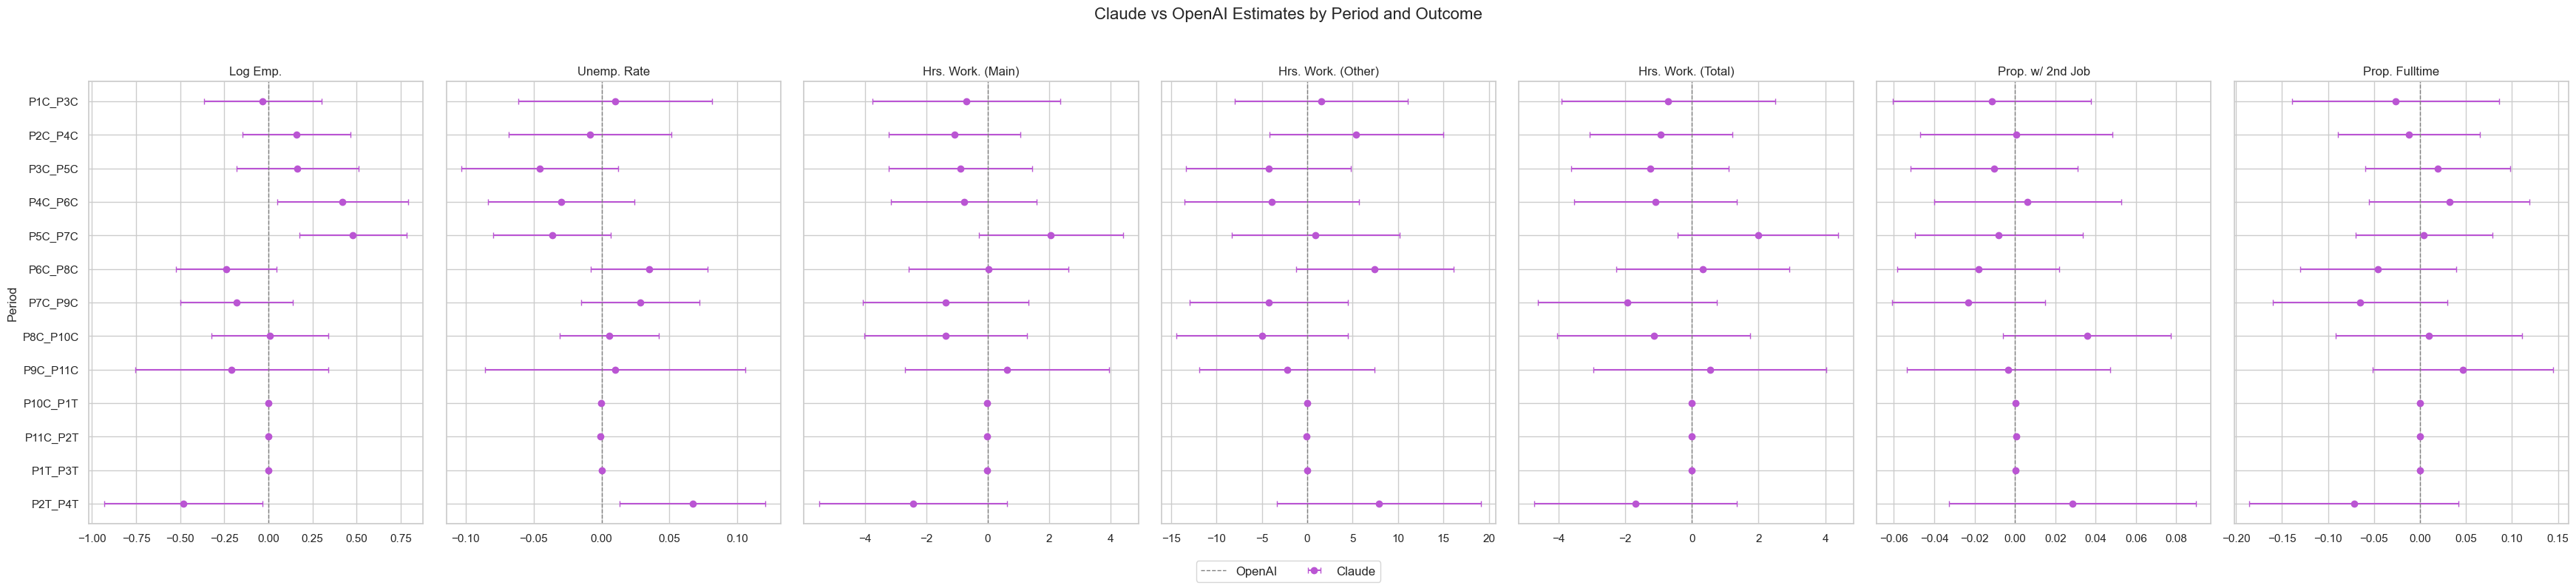

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Load and tag source ===
df_openai = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
df_openai['model'] = 'OpenAI'

df_claude = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates.csv")
df_claude['model'] = 'Claude'

# === Step 2: Combine and clean ===
df_all = pd.concat([df_openai, df_claude], ignore_index=True)

# Rename outcome labels
outcome_map = {
    'd_log_emp': 'Log Emp.',
    'd_unemp_rate': 'Unemp. Rate',
    'd_ahrswork1': 'Hrs. Work. (Main)',
    'd_ahrswork2': 'Hrs. Work. (Other)',
    'd_ahrsworkt': 'Hrs. Work. (Total)',
    'd_other_job': 'Prop. w/ 2nd Job',
    'd_fulltime': 'Prop. Fulltime'
}
df_all['outcome_clean'] = df_all['outcome'].map(outcome_map)

# Construct CIs based on 'coef' and 'se'
df_all['ci_lower'] = df_all['coef'] - 1.96 * df_all['stderr']
df_all['ci_upper'] = df_all['coef'] + 1.96 * df_all['stderr']

# Sort periods for plotting
df_all['period'] = df_all['period'].astype(str)
sorted_periods = sorted(df_all['period'].dropna().unique(), reverse=True)
df_all['period'] = pd.Categorical(df_all['period'], categories=sorted_periods, ordered=True)

# === Step 3: Plotting ===
sns.set(style="whitegrid")
unique_outcomes = df_all['outcome_clean'].dropna().unique()
n_outcomes = len(unique_outcomes)

fig, axes = plt.subplots(nrows=1, ncols=n_outcomes, figsize=(5 * n_outcomes, 8), sharey=True)
if n_outcomes == 1:
    axes = [axes]  # make iterable if only 1 outcome

for i, outcome in enumerate(unique_outcomes):
    ax = axes[i]
    sub = df_all[df_all['outcome_clean'] == outcome]

    for model, color in zip(['OpenAI', 'Claude'], ['mediumorchid', 'mediumseagreen']):
        data = sub[sub['model'] == model]
        ax.errorbar(
            x=data['coef'],
            y=data['period'],
            xerr=[data['coef'] - data['ci_lower'], data['ci_upper'] - data['coef']],
            fmt='o', label=model if i == 0 else "", capsize=3, color=color
        )

    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(outcome)
    ax.set_xlabel("")

axes[0].set_ylabel("Period")
fig.suptitle("Claude vs OpenAI Estimates by Period and Outcome", fontsize=16)
fig.legend(["OpenAI", "Claude"], loc='lower center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


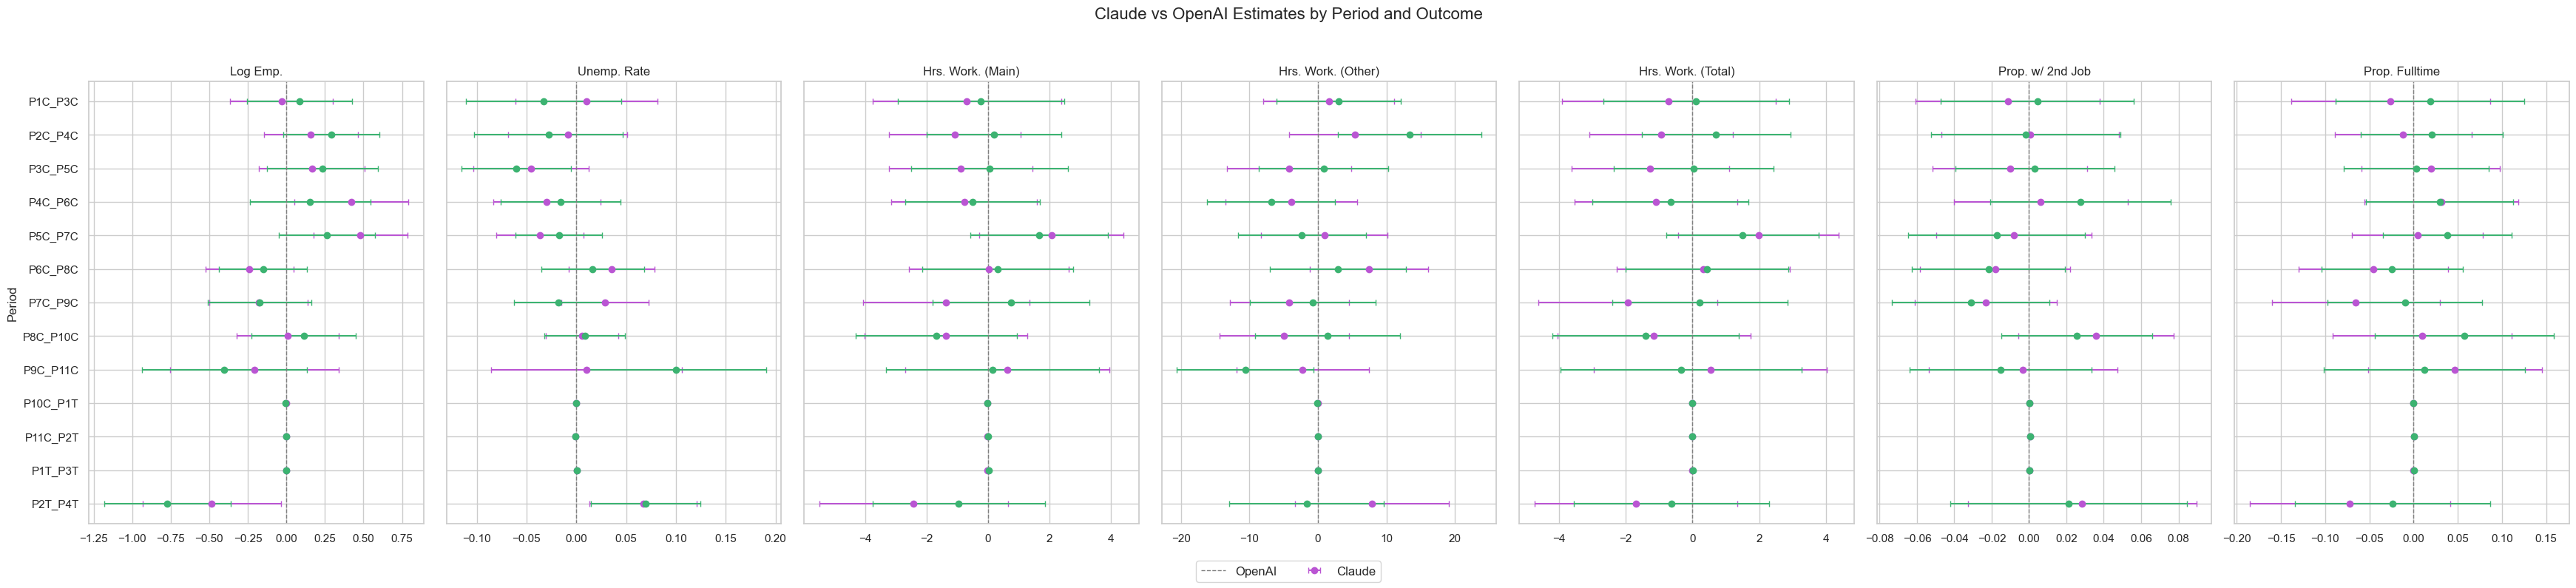

In [36]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load and label OpenAI and Claude data ===
df_openai = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")  # Replace with actual path
df_openai['model'] = 'OpenAI'

df_claude = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")  # Updated Claude file with periods
df_claude['model'] = 'Claude'

# === Combine datasets ===
df_all = pd.concat([df_openai, df_claude], ignore_index=True)

# === Clean outcome labels ===
outcome_map = {
    'd_log_emp': 'Log Emp.',
    'd_unemp_rate': 'Unemp. Rate',
    'd_ahrswork1': 'Hrs. Work. (Main)',
    'd_ahrswork2': 'Hrs. Work. (Other)',
    'd_ahrsworkt': 'Hrs. Work. (Total)',
    'd_other_job': 'Prop. w/ 2nd Job',
    'd_fulltime': 'Prop. Fulltime'
}
df_all['outcome_clean'] = df_all['outcome'].map(outcome_map)

# === Construct confidence intervals ===
df_all['ci_lower'] = df_all['coef'] - 1.96 * df_all['stderr']
df_all['ci_upper'] = df_all['coef'] + 1.96 * df_all['stderr']

# Set custom period order from earliest to latest (top to bottom in plot)
custom_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all['period'] = pd.Categorical(df_all['period'], categories=custom_order[::-1], ordered=True)

# === Plotting ===
sns.set(style="whitegrid")
unique_outcomes = df_all['outcome_clean'].dropna().unique()
n_outcomes = len(unique_outcomes)

fig, axes = plt.subplots(nrows=1, ncols=n_outcomes, figsize=(5 * n_outcomes, 8), sharey=True)
if n_outcomes == 1:
    axes = [axes]  # ensure it's iterable

for i, outcome in enumerate(unique_outcomes):
    ax = axes[i]
    sub = df_all[df_all['outcome_clean'] == outcome]

    for model, color in zip(['OpenAI', 'Claude'], ['mediumorchid', 'mediumseagreen']):
        data = sub[sub['model'] == model]
        ax.errorbar(
            x=data['coef'],
            y=data['period'],
            xerr=[data['coef'] - data['ci_lower'], data['ci_upper'] - data['coef']],
            fmt='o', label=model if i == 0 else "", capsize=3, color=color
        )

    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(outcome)
    ax.set_xlabel("")

axes[0].set_ylabel("Period")
fig.suptitle("Claude vs OpenAI Estimates by Period and Outcome", fontsize=16)
fig.legend(["OpenAI", "Claude"], loc='lower center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



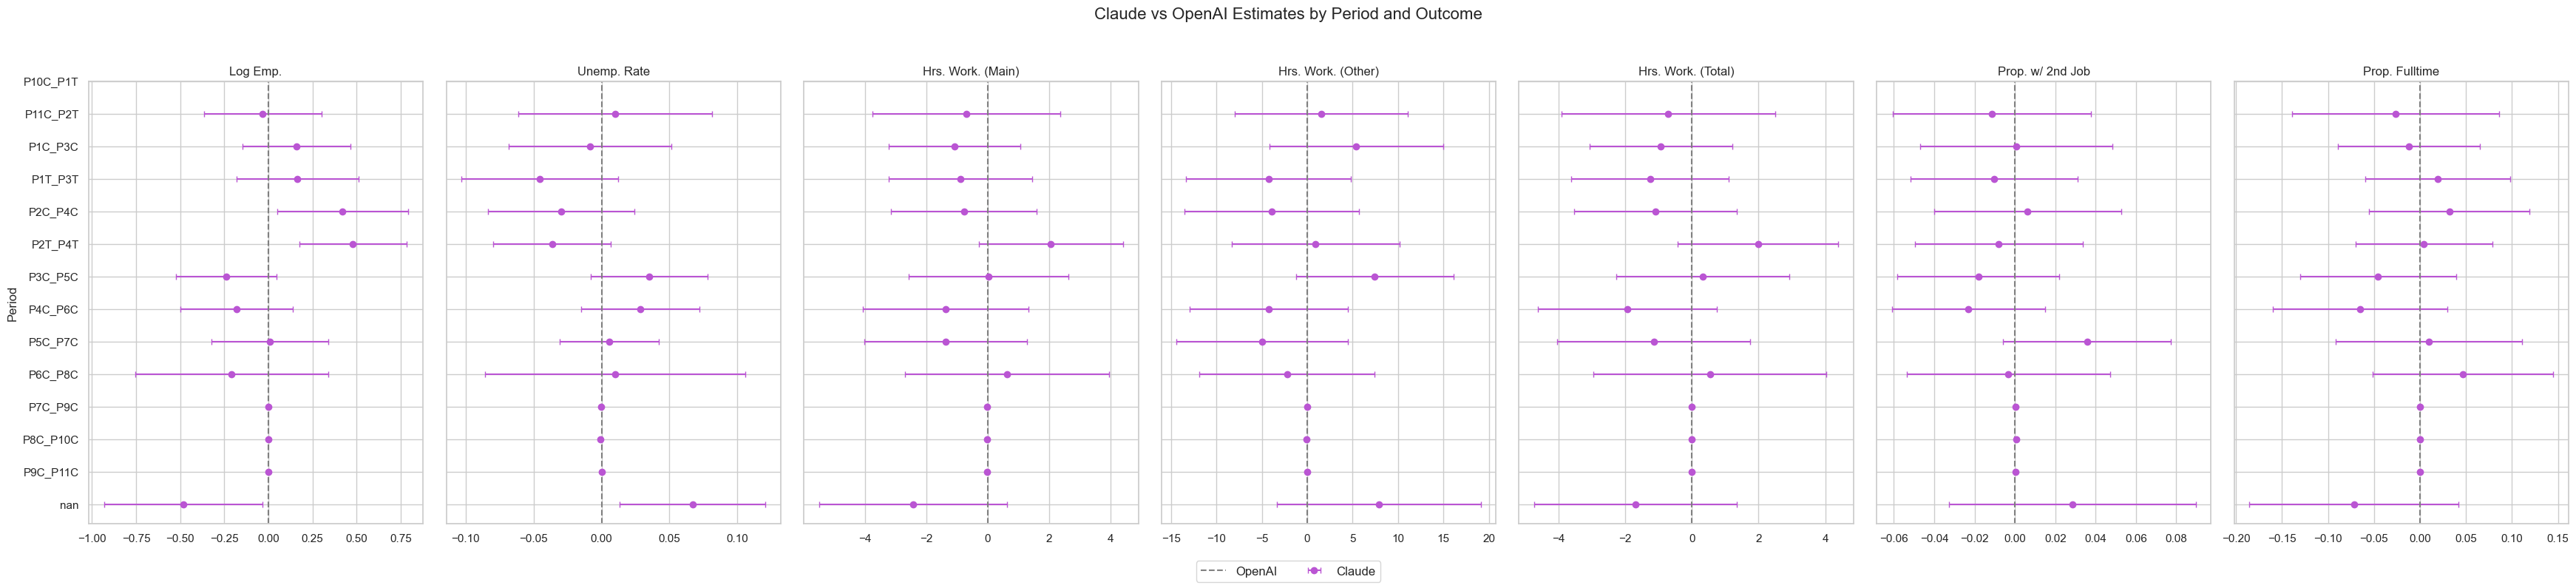

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load and tag sources ===
df_openai = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
df_openai["model"] = "OpenAI"

df_claude = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates.csv")
df_claude["model"] = "Claude"

# === Combine ===
df_all = pd.concat([df_openai, df_claude], ignore_index=True)

# === Clean outcome names ===
outcome_map = {
    'd_log_emp': 'Log Emp.',
    'd_unemp_rate': 'Unemp. Rate',
    'd_ahrswork1': 'Hrs. Work. (Main)',
    'd_ahrswork2': 'Hrs. Work. (Other)',
    'd_ahrsworkt': 'Hrs. Work. (Total)',
    'd_other_job': 'Prop. w/ 2nd Job',
    'd_fulltime': 'Prop. Fulltime'
}
df_all['outcome_clean'] = df_all['outcome'].map(outcome_map)

# === Construct CIs ===
df_all['ci_lower'] = df_all['coef'] - 1.96 * df_all['stderr']
df_all['ci_upper'] = df_all['coef'] + 1.96 * df_all['stderr']

# === Sort periods manually ===
df_all['period'] = df_all['period'].astype(str)
all_periods = sorted(df_all['period'].dropna().unique(), reverse=True)
df_all['period'] = pd.Categorical(df_all['period'], categories=all_periods, ordered=True)

# === Plot ===
sns.set(style="whitegrid")
outcomes = df_all['outcome_clean'].dropna().unique()
n_outcomes = len(outcomes)

fig, axes = plt.subplots(nrows=1, ncols=n_outcomes, figsize=(5 * n_outcomes, 8), sharey=True)
if n_outcomes == 1:
    axes = [axes]

for i, outcome in enumerate(outcomes):
    ax = axes[i]
    sub = df_all[df_all['outcome_clean'] == outcome]

    for model, color in zip(['OpenAI', 'Claude'], ['mediumorchid', 'mediumseagreen']):
        model_data = sub[sub['model'] == model]
        ax.errorbar(
            x=model_data['coef'],
            y=model_data['period'],
            xerr=[model_data['coef'] - model_data['ci_lower'], model_data['ci_upper'] - model_data['coef']],
            fmt='o', label=model if i == 0 else "", capsize=3, color=color
        )

    ax.set_title(outcome)
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel("")
    ax.set_yticks(range(len(all_periods)))
    ax.set_yticklabels(all_periods)

axes[0].set_ylabel("Period")
fig.suptitle("Claude vs OpenAI Estimates by Period and Outcome", fontsize=16)
fig.legend(["OpenAI", "Claude"], loc='lower center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


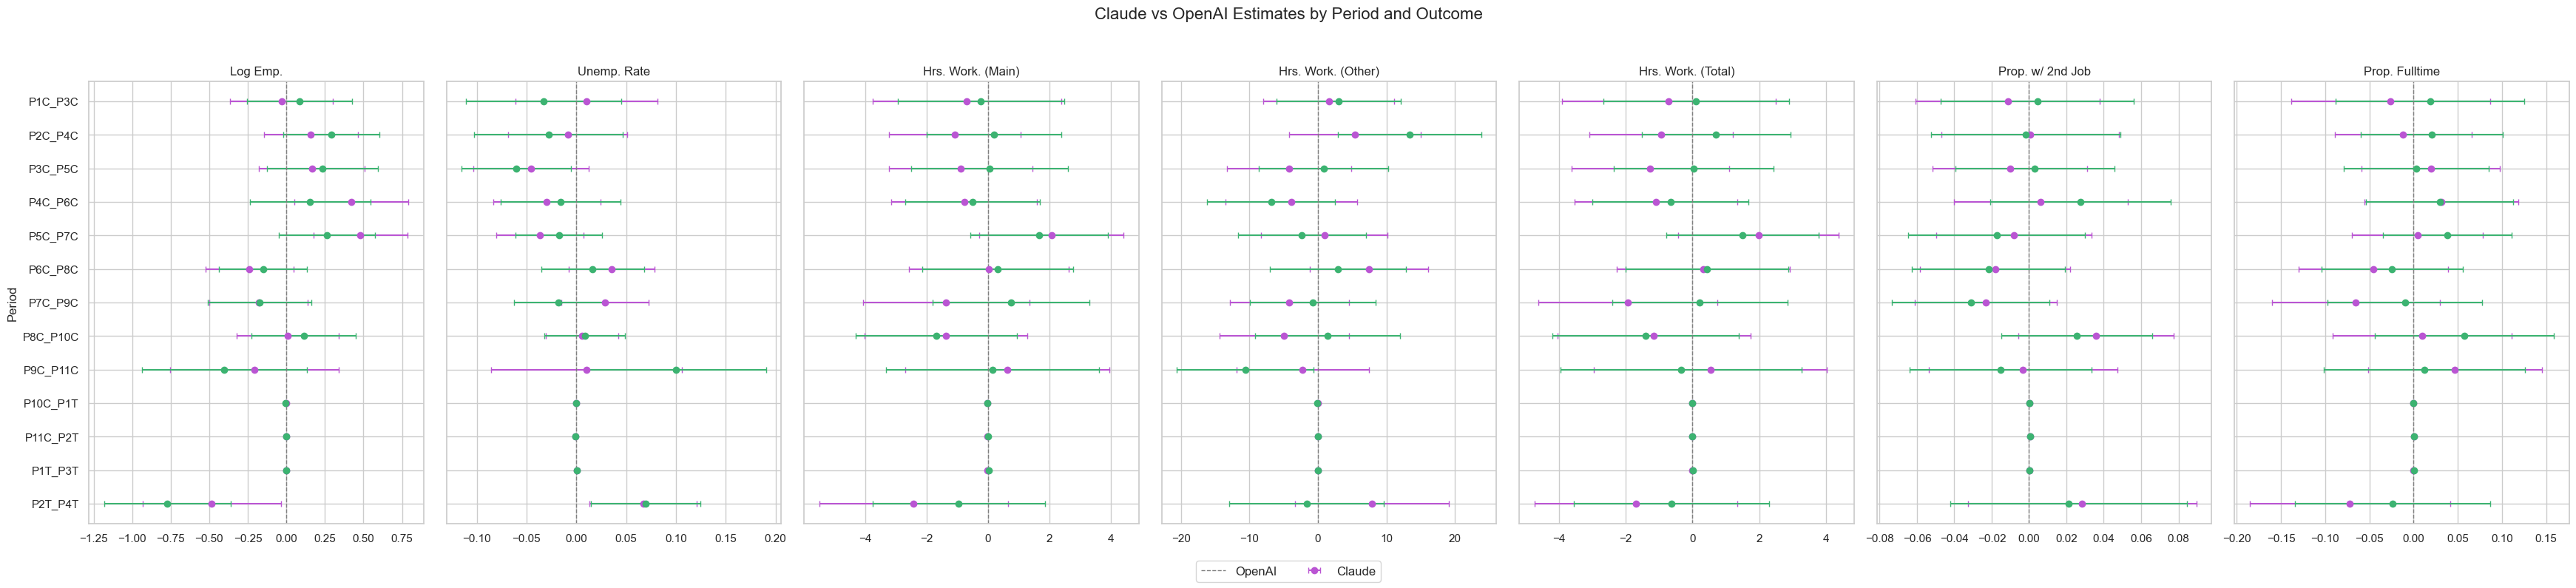

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs
df_openai = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
df_openai['model'] = 'OpenAI'

df_claude = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")
df_claude['model'] = 'Claude'

# Combine and clean
df_all = pd.concat([df_openai, df_claude], ignore_index=True)

# Label outcomes
outcome_map = {
    'd_log_emp': 'Log Emp.',
    'd_unemp_rate': 'Unemp. Rate',
    'd_ahrswork1': 'Hrs. Work. (Main)',
    'd_ahrswork2': 'Hrs. Work. (Other)',
    'd_ahrsworkt': 'Hrs. Work. (Total)',
    'd_other_job': 'Prop. w/ 2nd Job',
    'd_fulltime': 'Prop. Fulltime'
}
df_all['outcome_clean'] = df_all['outcome'].map(outcome_map)

# Confidence intervals
df_all['ci_lower'] = df_all['coef'] - 1.96 * df_all['stderr']
df_all['ci_upper'] = df_all['coef'] + 1.96 * df_all['stderr']

# Ensure proper period ordering
custom_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all['period'] = pd.Categorical(df_all['period'], categories=custom_order, ordered=True)

# Plotting
sns.set(style="whitegrid")
unique_outcomes = df_all['outcome_clean'].dropna().unique()
n_outcomes = len(unique_outcomes)

fig, axes = plt.subplots(nrows=1, ncols=n_outcomes, figsize=(5 * n_outcomes, 8), sharey=True)
if n_outcomes == 1:
    axes = [axes]

for i, outcome in enumerate(unique_outcomes):
    ax = axes[i]
    sub = df_all[df_all['outcome_clean'] == outcome]

    for model, color in zip(['OpenAI', 'Claude'], ['mediumorchid', 'mediumseagreen']):
        data = sub[sub['model'] == model]
        ax.errorbar(
            x=data['coef'],
            y=data['period'],
            xerr=[data['coef'] - data['ci_lower'], data['ci_upper'] - data['coef']],
            fmt='o', label=model if i == 0 else "", capsize=3, color=color
        )

    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(outcome)
    ax.set_xlabel("")

axes[0].set_ylabel("Period")
fig.suptitle("Claude vs OpenAI Estimates by Period and Outcome", fontsize=16)
fig.legend(["OpenAI", "Claude"], loc='lower center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")

# === Add source label and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Fix missing *100 scaling for 3 affected periods
scale_fix_periods = ["P10C_P1T", "P11C_P2T", "P1T_P3T"]
mask = df_all["period"].isin(scale_fix_periods)

# Multiply coefficients, stderr, and confidence intervals by 100 for affected rows
for col in ["coef", "stderr", "ci_lower", "ci_upper"]:
    df_all.loc[mask, col] = df_all.loc[mask, col] * 100

# === Period order ===
period_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all["period"] = pd.Categorical(df_all["period"], categories=period_order, ordered=True)

# === Nicer outcome labels ===
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Main Hours Worked",
    "d_ahrswork2": "Other Hours Worked",
    "d_ahrsworkt": "Total Hours Worked",
    "d_other_job": "Second Job Share",
    "d_fulltime": "Full-time Share"
}

# === Colors ===
palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}  # Purple and green

# === Plot setup ===
sns.set(style="whitegrid")

for outcome in df_all["outcome"].unique():
    df_sub = df_all[df_all["outcome"] == outcome].copy()
    
    plt.figure(figsize=(9, 6))
    ax = sns.pointplot(
        data=df_sub,
        x="coef",
        y="period",
        hue="model",
        dodge=0.5,
        palette=palette,
        markers="s",
        linestyles="none",  # suppress lines between points
        errorbar=None
    )

    # Add manual error bars
    for i, row in df_sub.iterrows():
        y_pos = list(period_order).index(row["period"])
        offset = -0.2 if row["model"] == "OpenAI" else 0.2
        plt.errorbar(
            x=row["coef"],
            y=y_pos + offset,
            xerr=[[row["coef"] - row["ci_lower"]], [row["ci_upper"] - row["coef"]]],
            fmt='none',
            ecolor=palette[row["model"]],
            capsize=3,
            linewidth=1
        )

    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(outcome_labels.get(outcome, outcome), fontsize=14)
    plt.xlabel("Coefficient")
    plt.ylabel("Period")
    plt.gca().invert_yaxis()
    plt.legend(title="", loc="best")
    plt.tight_layout()
    filename = f"{outcome}_panel_plot.png"
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.close()


Saved: d_log_emp_panel_plot.png
Saved: d_unemp_rate_panel_plot.png
Saved: d_ahrswork1_panel_plot.png
Saved: d_ahrswork2_panel_plot.png
Saved: d_ahrsworkt_panel_plot.png
Saved: d_other_job_panel_plot.png
Saved: d_fulltime_panel_plot.png


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")

# === Add model label and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Fix missing *100 scaling for 3 affected periods
scale_fix_periods = ["P10C_P1T", "P11C_P2T", "P1T_P3T"]
mask = df_all["period"].isin(scale_fix_periods)

# Multiply coefficients, stderr, and confidence intervals by 100 for affected rows
for col in ["coef", "stderr", "ci_lower", "ci_upper"]:
    df_all.loc[mask, col] = df_all.loc[mask, col] * 100


# === Clean and normalize period labels ===
df_all["period"] = df_all["period"].str.strip().str.upper()

# === Set ordered period list ===
period_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all["period"] = pd.Categorical(df_all["period"], categories=period_order, ordered=True)

# === Clean labels for plotting titles ===
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Main Hours Worked",
    "d_ahrswork2": "Other Hours Worked",
    "d_ahrsworkt": "Total Hours Worked",
    "d_other_job": "Second Job Share",
    "d_fulltime": "Full-time Share"
}

# === Color palette ===
palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}  # Purple and green

# === Plot aesthetics ===
sns.set(style="whitegrid")

# === Plot each outcome ===
for outcome in df_all["outcome"].unique():
    df_sub = df_all[df_all["outcome"] == outcome].copy()

    plt.figure(figsize=(9, 6))
    ax = sns.pointplot(
        data=df_sub,
        x="coef",
        y="period",
        hue="model",
        dodge=0.5,
        palette=palette,
        markers="s",
        linestyles="none",
        errorbar=None,
        markersize=8
    )

    # === Determine y-tick positions
    y_locs = dict(zip([t.get_text() for t in ax.get_yticklabels()], ax.get_yticks()))

    # === Plot error bars
    for _, row in df_sub.iterrows():
        period_label = str(row["period"]).strip().upper()
        y = y_locs.get(period_label, None)
        if y is not None:
            offset = -0.2 if row["model"] == "OpenAI" else 0.2
            left = row["coef"] - row["ci_lower"]
            right = row["ci_upper"] - row["coef"]
            plt.errorbar(
                x=row["coef"],
                y=y + offset,
                xerr=[[left], [right]],
                fmt='none',
                ecolor=palette[row["model"]],
                capsize=3,
                linewidth=1
            )

        else:
            print(f"⚠️ Missing y-tick position for: {period_label}")

    # === Finish plot
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(outcome_labels.get(outcome, outcome), fontsize=14)
    plt.xlabel("Coefficient")
    plt.ylabel("Period")
    plt.gca().invert_yaxis()
    plt.legend(title="", loc="best")
    plt.tight_layout()
    
    filename = f"{outcome}_panel_plot.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.close()


✅ Saved: d_log_emp_panel_plot.png
✅ Saved: d_unemp_rate_panel_plot.png
✅ Saved: d_ahrswork1_panel_plot.png
✅ Saved: d_ahrswork2_panel_plot.png
✅ Saved: d_ahrsworkt_panel_plot.png
✅ Saved: d_other_job_panel_plot.png
✅ Saved: d_fulltime_panel_plot.png


✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_log_emp_over_time.png


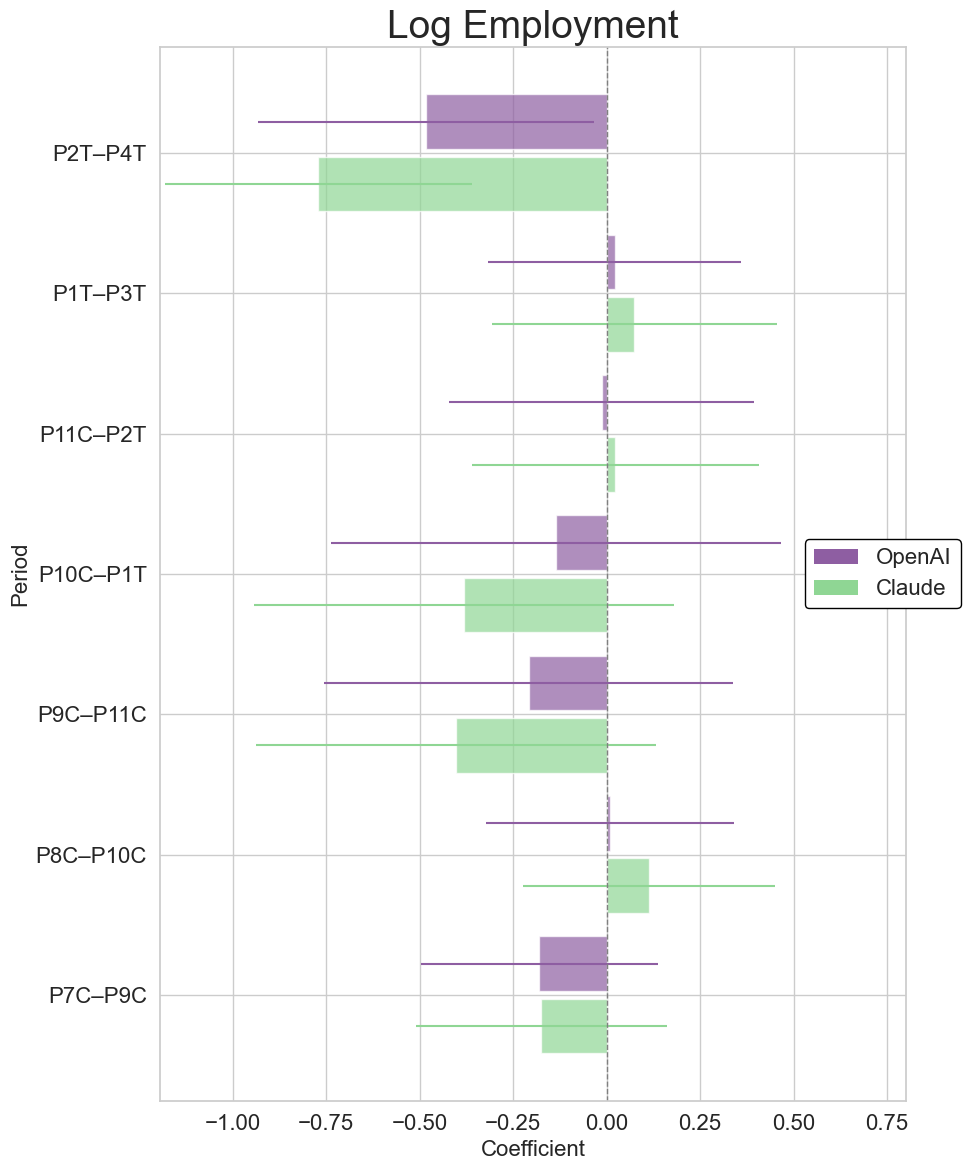

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_unemp_rate_over_time.png


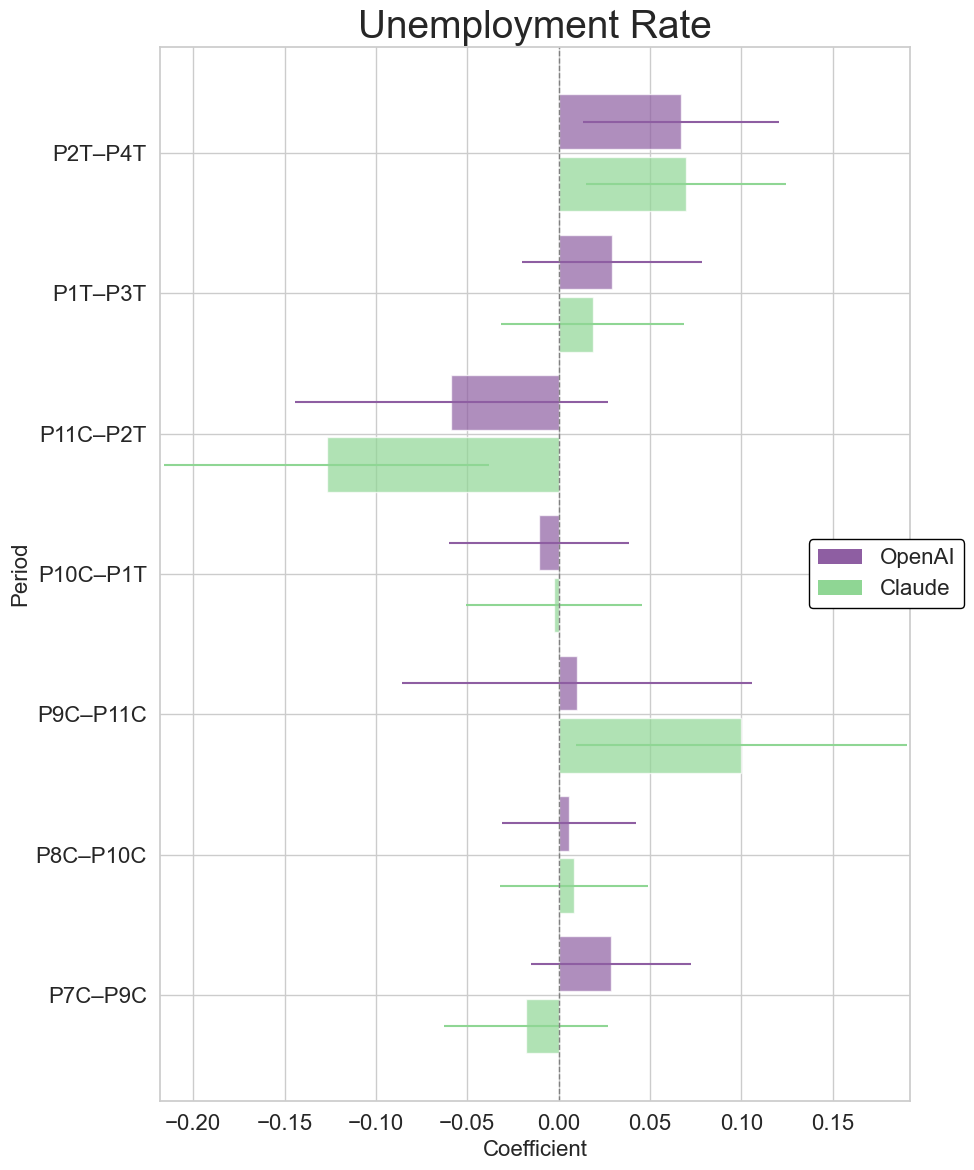

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_ahrswork1_over_time.png


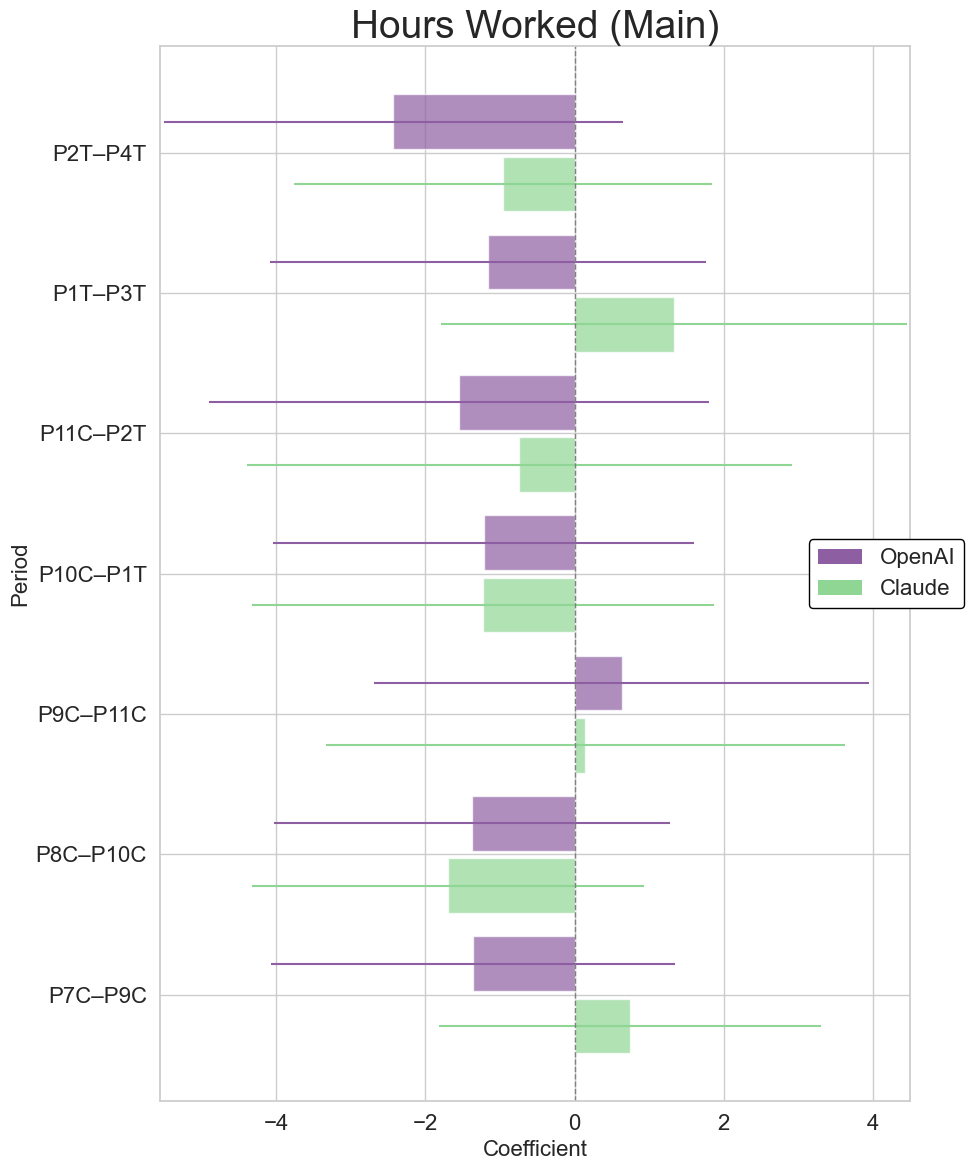

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_ahrswork2_over_time.png


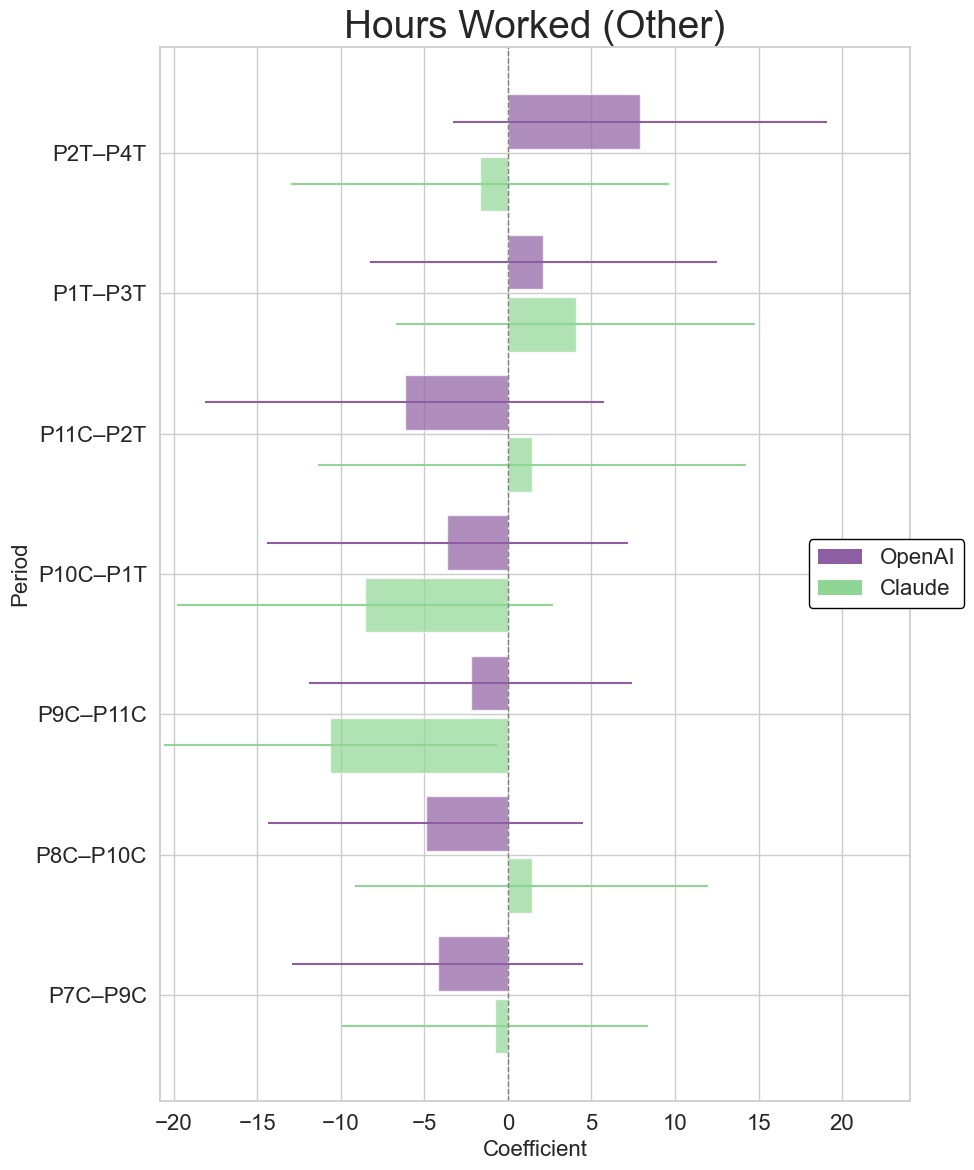

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_ahrsworkt_over_time.png


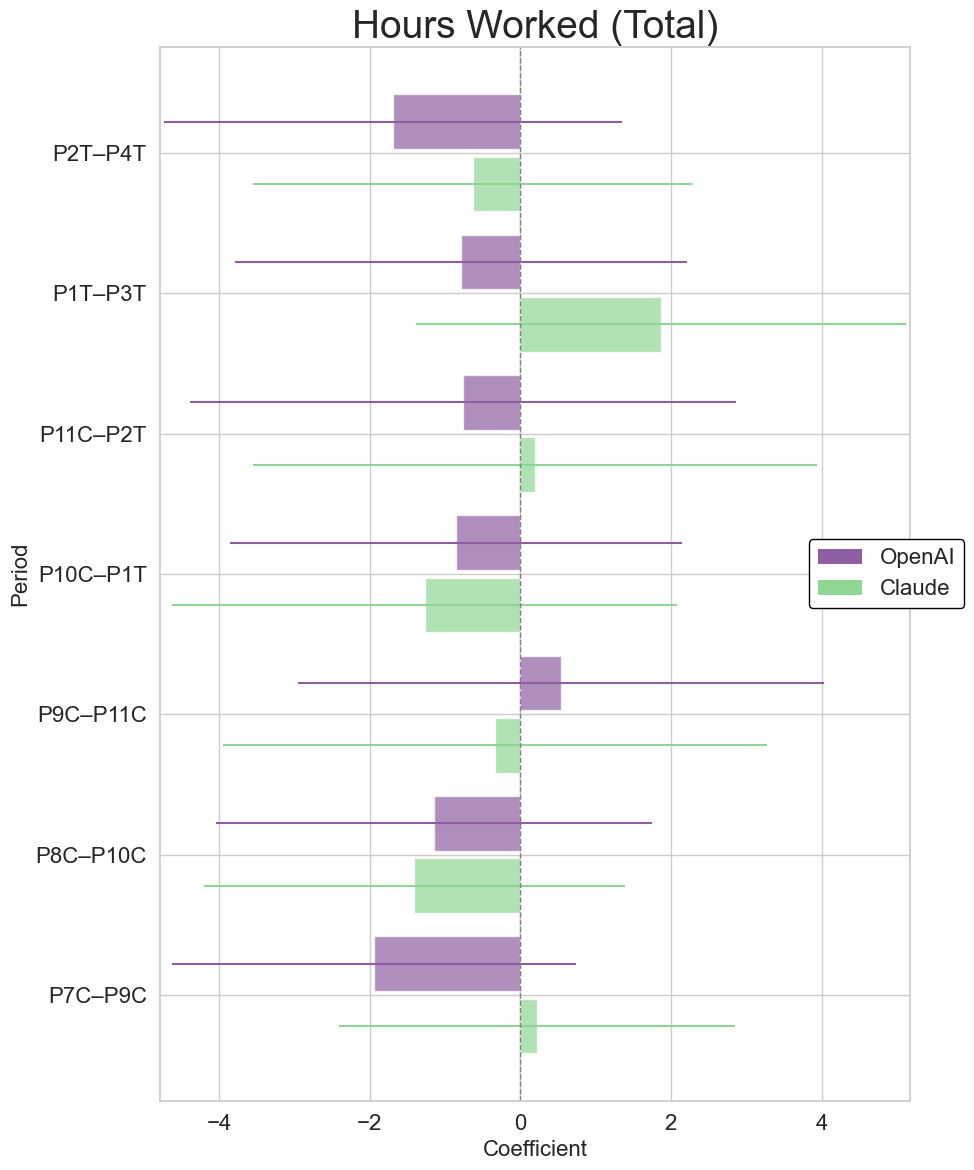

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_other_job_over_time.png


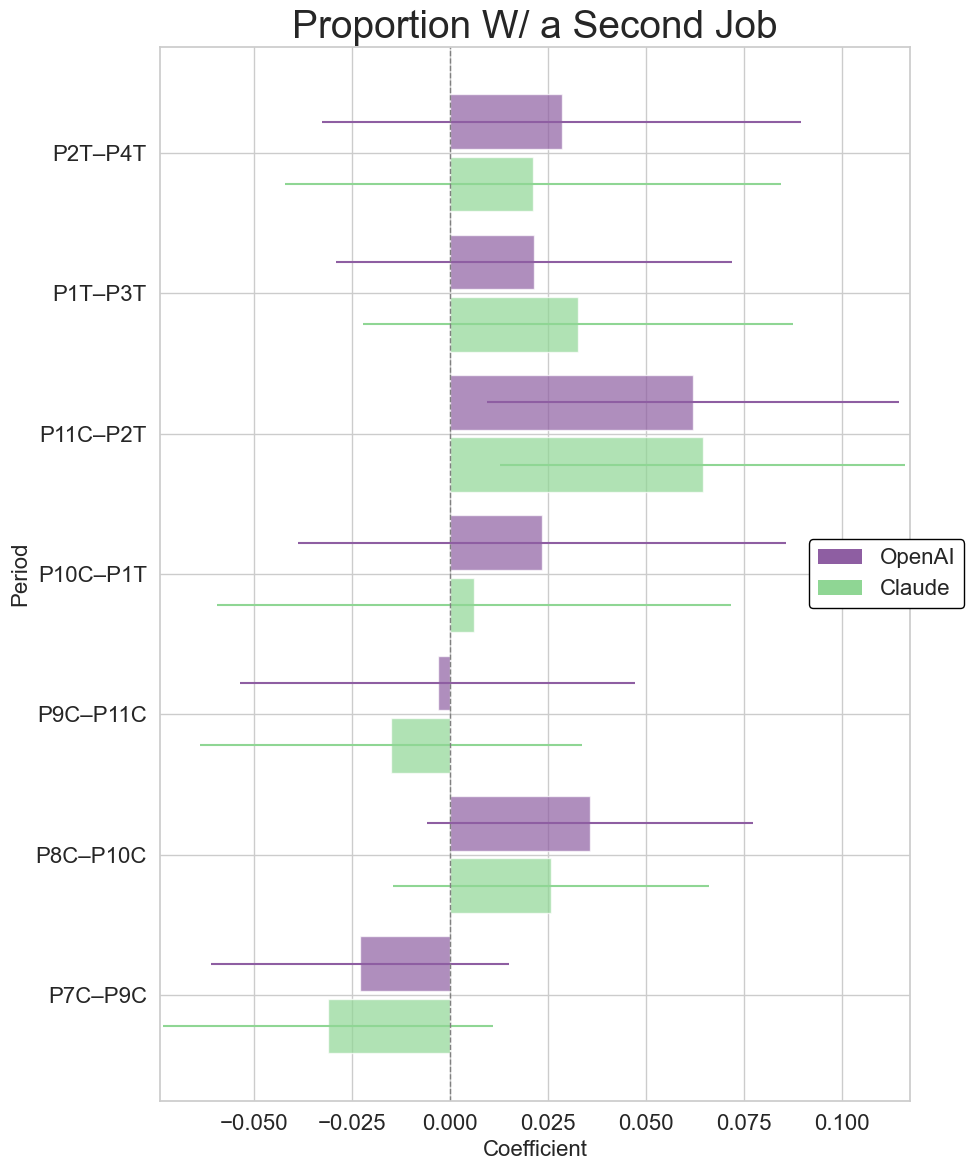

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel/d_fulltime_over_time.png


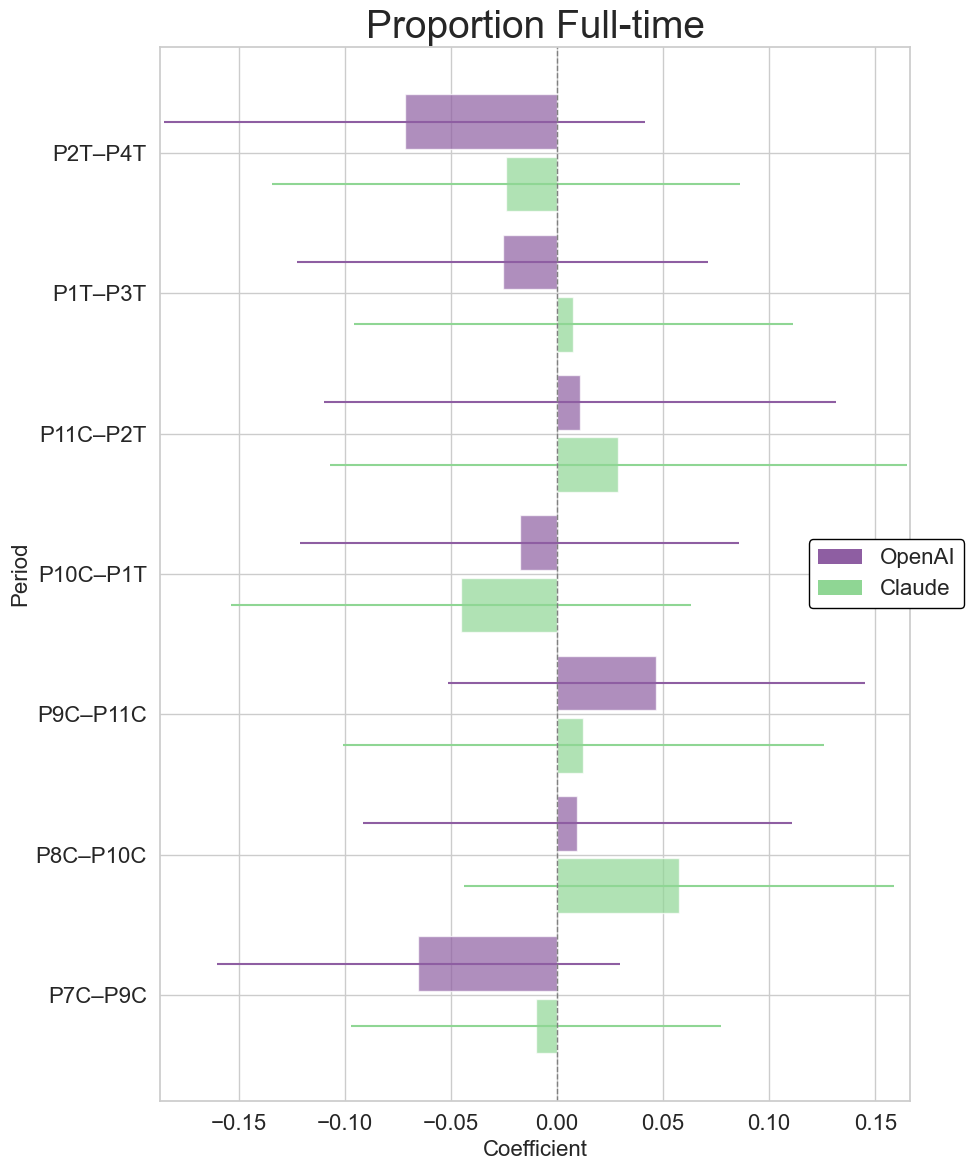

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import os

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")

# === Add model labels and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Normalize period labels ===
df_all["period"] = df_all["period"].str.strip().str.upper()

# === Set period order ===
period_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all["period"] = pd.Categorical(df_all["period"], categories=period_order, ordered=True)

# === Fix scale bug in 3 periods that were missing *100 transformation
scale_fix_periods = ["P10C_P1T", "P11C_P2T", "P1T_P3T"]
mask = df_all["period"].isin(scale_fix_periods)
for col in ["coef", "stderr", "ci_lower", "ci_upper"]:
    df_all.loc[mask, col] = df_all.loc[mask, col] * 100

# === Clean labels for plotting
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Hours Worked (Main)",
    "d_ahrswork2": "Hours Worked (Other)",
    "d_ahrsworkt": "Hours Worked (Total)",
    "d_other_job": "Proportion W/ a Second Job",
    "d_fulltime": "Proportion Full-time"
}

# === Color palette
palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}

# === Output directory
output_dir = "/Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel"
os.makedirs(output_dir, exist_ok=True)

# === Start plotting
sns.set(style="whitegrid")

for outcome in df_all["outcome"].unique():
    df_sub = df_all[df_all["outcome"] == outcome].copy()
    df_sub = df_sub.sort_values("period", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 11.5))

    # Define top 7 periods starting from "P7C_P9C" onward
    top_periods = ["P7C_P9C", "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"]
    periods = [p for p in top_periods if p in df_sub["period"].unique()][::-1]

    spacing = 1.8  # Increased spacing between rows
    model_offset = {"OpenAI": -0.4, "Claude": 0.4}  # Adjusted for wider gap

    for i, period in enumerate(periods):
        for model in ["OpenAI", "Claude"]:
            row = df_sub[(df_sub["period"] == period) & (df_sub["model"] == model)]
            if row.empty:
                continue
            row = row.iloc[0]
            y = i * spacing + model_offset[model]

            # Confidence interval line
            ax.hlines(
                y=y,
                xmin=row["ci_lower"],
                xmax=row["ci_upper"],
                color=palette[model],
                linewidth=1.5
            )

            # Coefficient bar
            ax.barh(
                y=y,
                width=row["coef"],
                height=0.7,  
                color=palette[model],
                alpha=0.7
            )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_yticks([i * spacing for i in range(len(periods))])
    ax.set_yticklabels([p.replace("_", "–") for p in periods])
    ax.set_xlabel("Coefficient", fontsize=16)
    ax.set_ylabel("Period", fontsize=16)
    ax.set_title(outcome_labels.get(outcome, outcome), fontsize=28)
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)


    # Legend
    legend_elements = [
        Patch(facecolor=palette["OpenAI"], edgecolor='none', label='OpenAI'),
        Patch(facecolor=palette["Claude"], edgecolor='none', label='Claude'),
    ]
    ax.legend(handles=legend_elements, loc='best')

    # Get max/min value across all models for that outcome
    x_min = df_sub["ci_lower"].min()
    x_max = df_sub["ci_upper"].max()
    ax.set_xlim(x_min * 1.01, x_max * 1.01)

    plt.tight_layout(pad=0)

    ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(.85, 0.5),
    frameon=True,  # ← This adds the box
    framealpha=1,  # Optional: controls transparency of the box
    edgecolor='black',  # Optional: box border color
    fontsize=16  # Optional: adjusts legend text size
)

    # Save with tight layout to trim white space
    filename = os.path.join(output_dir, f"{outcome}_over_time.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {filename}")
    plt.show()



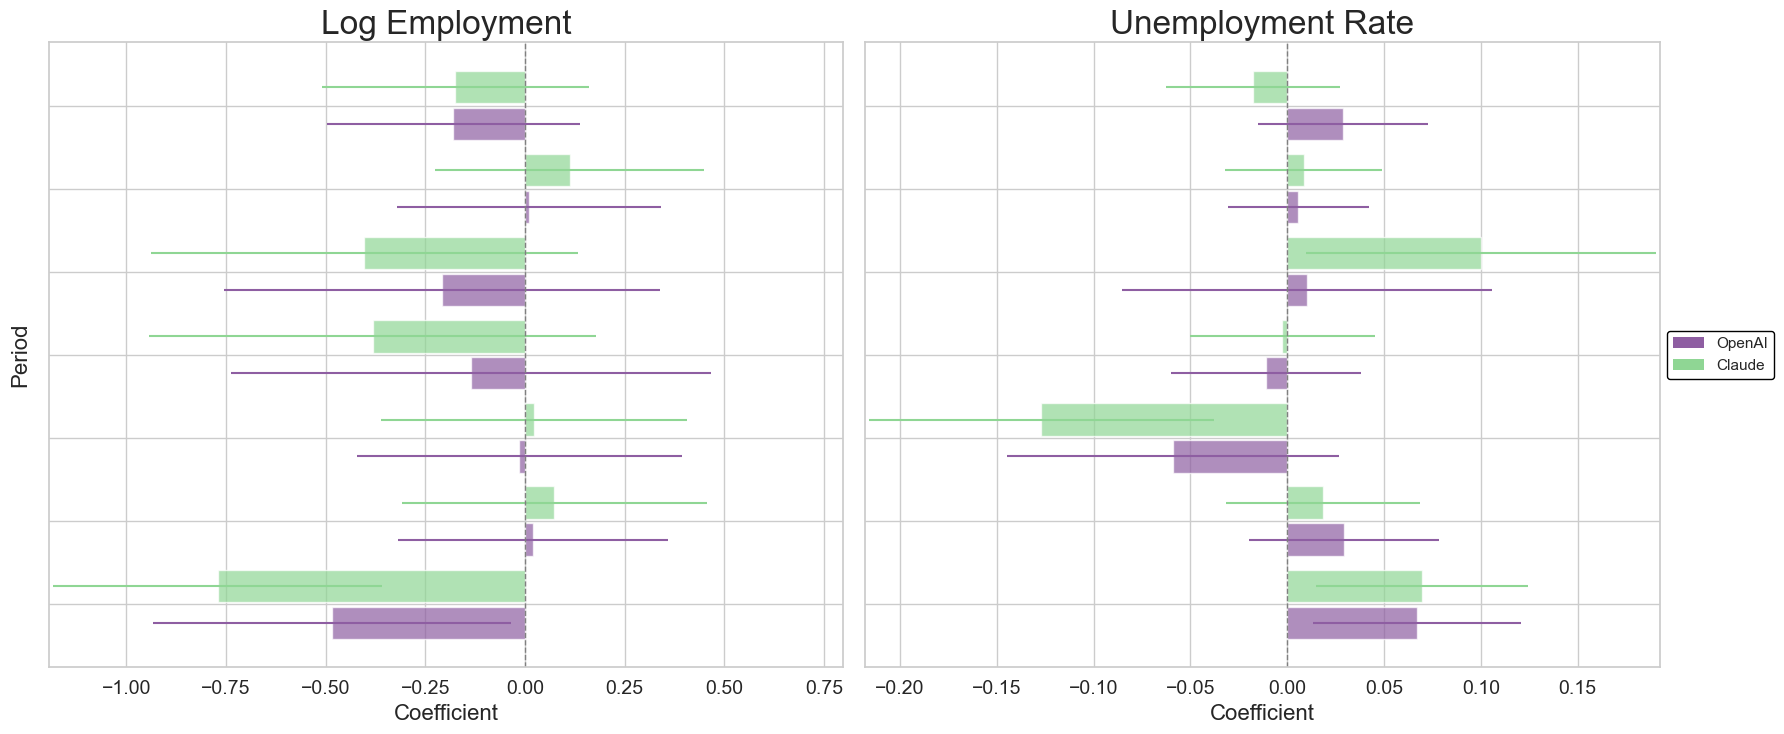

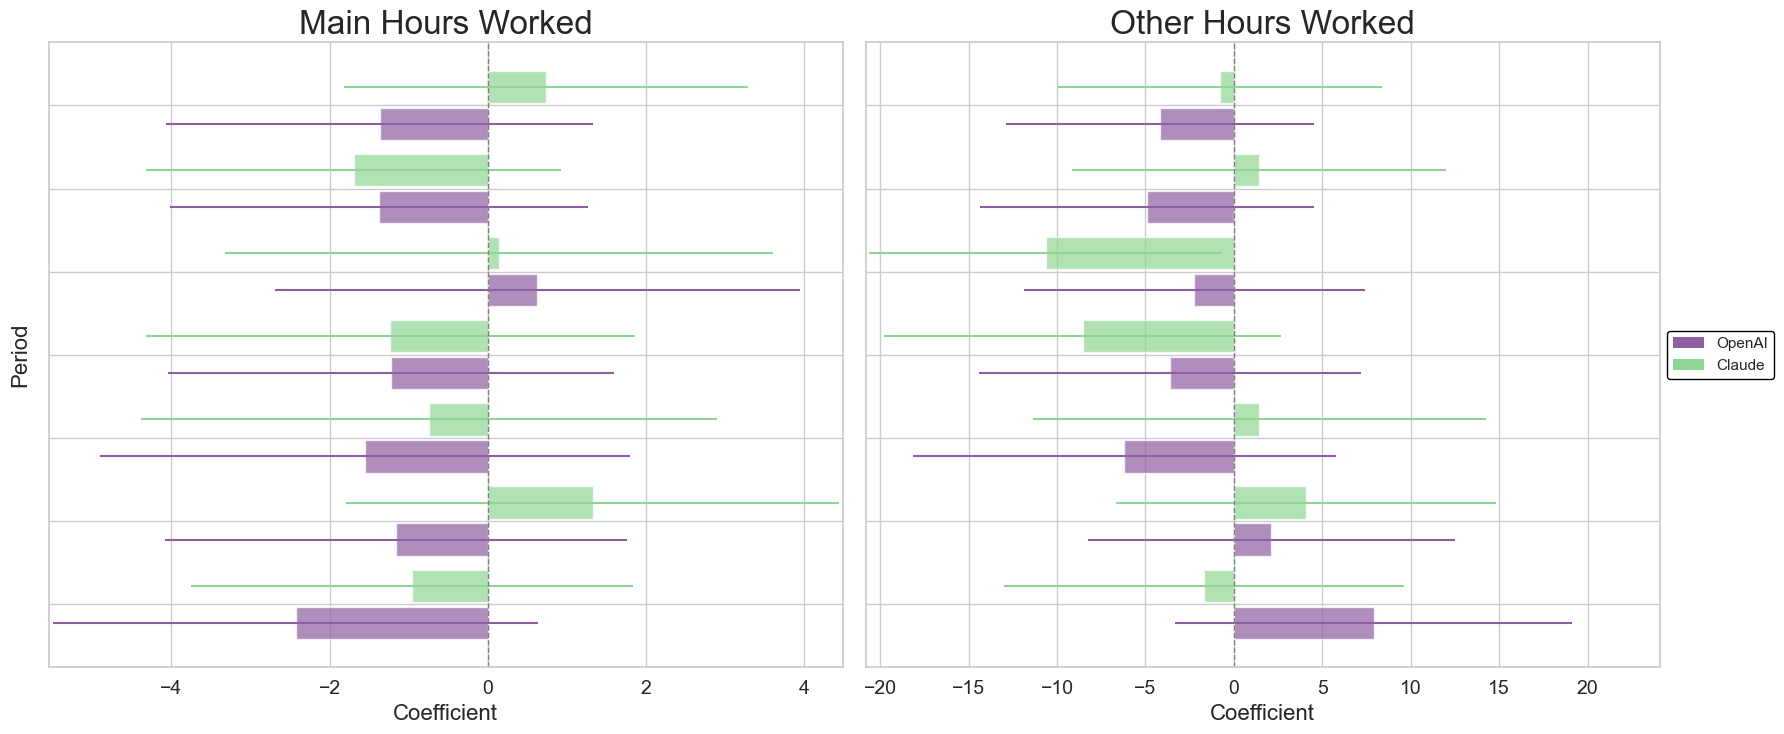

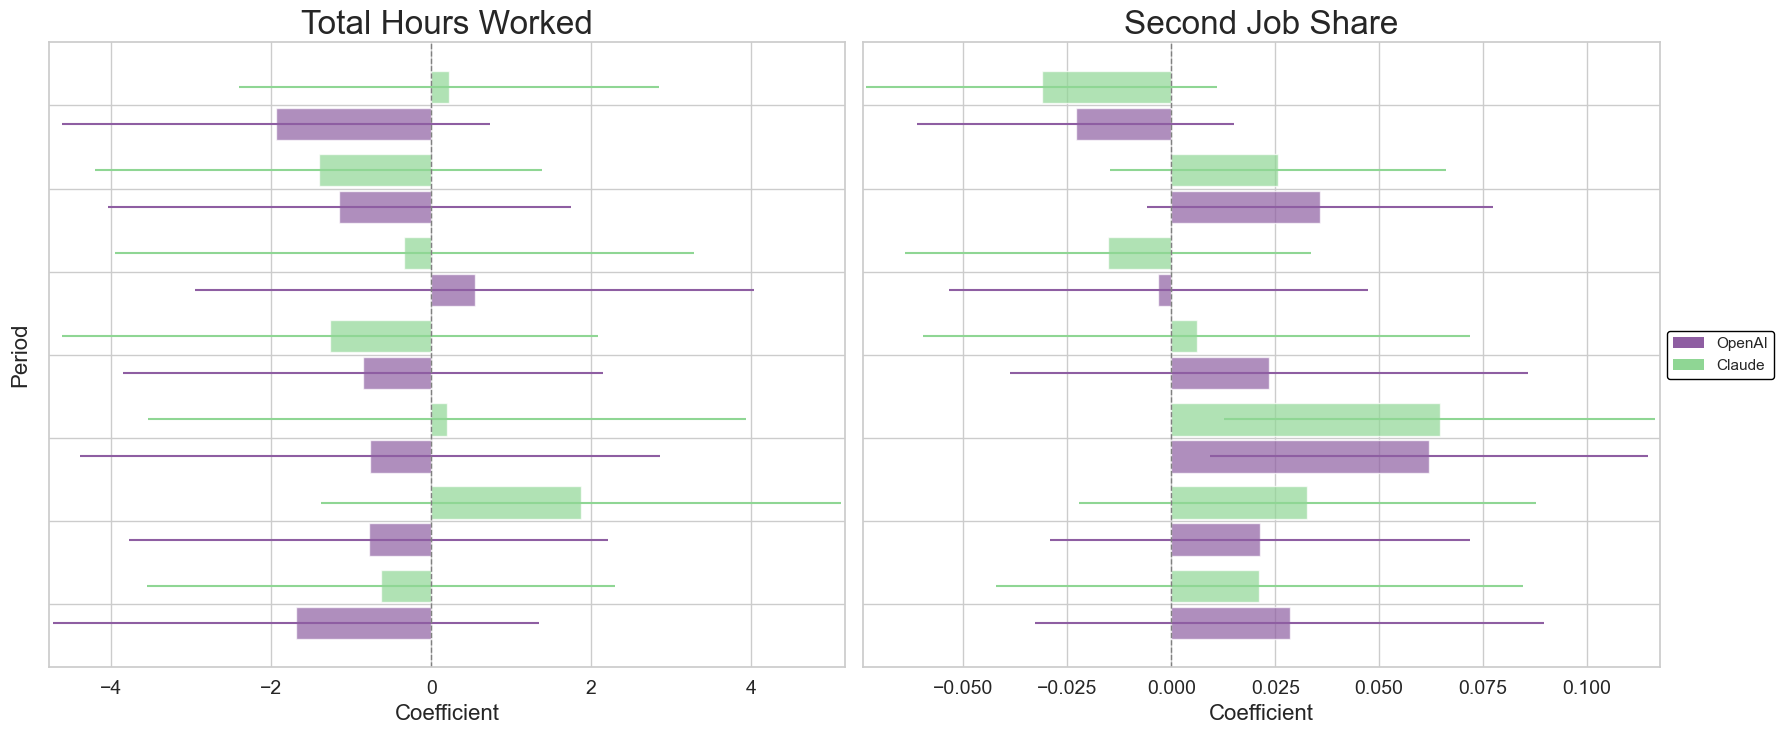

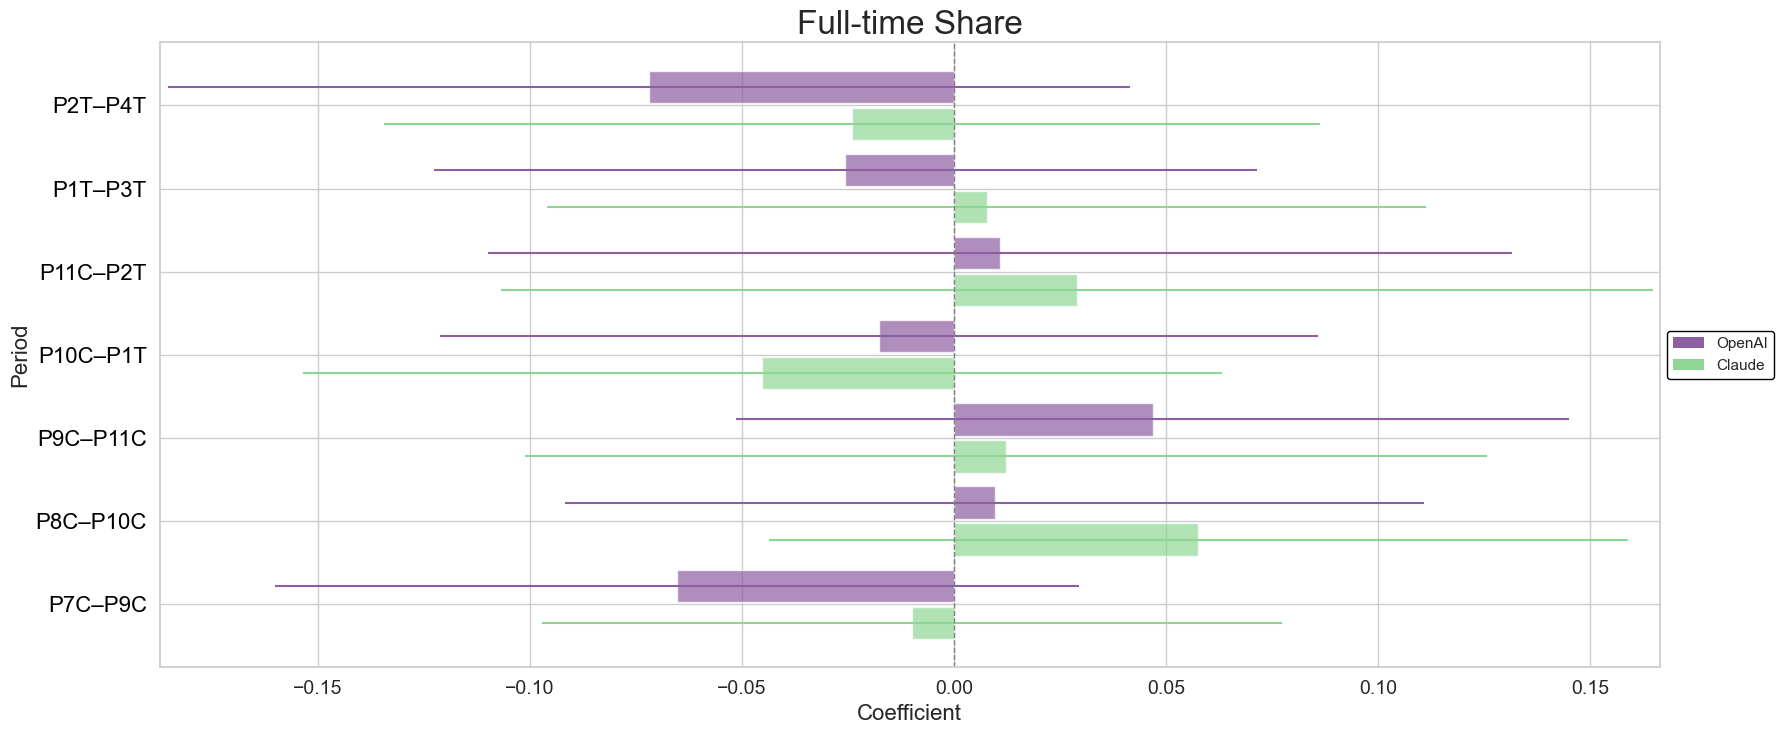

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import os

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/openai_panel_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_12/claude_panel_estimates_with_period.csv")

# === Add model labels and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Normalize period labels ===
df_all["period"] = df_all["period"].str.strip().str.upper()

# === Set period order ===
period_order = [
    "P1C_P3C", "P2C_P4C", "P3C_P5C", "P4C_P6C", "P5C_P7C", "P6C_P8C", "P7C_P9C",
    "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"
]
df_all["period"] = pd.Categorical(df_all["period"], categories=period_order, ordered=True)

# === Fix scale bug in 3 periods that were missing *100 transformation
scale_fix_periods = ["P10C_P1T", "P11C_P2T", "P1T_P3T"]
mask = df_all["period"].isin(scale_fix_periods)
for col in ["coef", "stderr", "ci_lower", "ci_upper"]:
    df_all.loc[mask, col] = df_all.loc[mask, col] * 100

# === Clean labels for plotting
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Main Hours Worked",
    "d_ahrswork2": "Other Hours Worked",
    "d_ahrsworkt": "Total Hours Worked",
    "d_other_job": "Second Job Share",
    "d_fulltime": "Full-time Share"
}

palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}
output_dir = "/Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_panel_combined"
os.makedirs(output_dir, exist_ok=True)
sns.set(style="whitegrid")

outcomes = list(df_all["outcome"].unique())
pairs = [outcomes[i:i + 2] for i in range(0, len(outcomes), 2)]

for pair in pairs:
    fig, axes = plt.subplots(nrows=1, ncols=len(pair), figsize=(18, 7.5), sharey=True)

    if len(pair) == 1:
        axes = [axes]  # Ensure list even with one axis

    for ax_idx, (ax, outcome) in enumerate(zip(axes, pair)):
        df_sub = df_all[df_all["outcome"] == outcome].copy()
        df_sub = df_sub.sort_values("period", ascending=False)

        # Top 7 periods from P7C_P9C to P2T_P4T
        top_periods = ["P7C_P9C", "P8C_P10C", "P9C_P11C", "P10C_P1T", "P11C_P2T", "P1T_P3T", "P2T_P4T"]
        periods = [p for p in top_periods if p in df_sub["period"].unique()][::-1]

        spacing = 1.8
        model_offset = {"OpenAI": -0.4, "Claude": 0.4}

        for i, period in enumerate(periods):
            for model in ["OpenAI", "Claude"]:
                row = df_sub[(df_sub["period"] == period) & (df_sub["model"] == model)]
                if row.empty:
                    continue
                row = row.iloc[0]
                y = i * spacing + model_offset[model]

                ax.hlines(
                    y=y,
                    xmin=row["ci_lower"],
                    xmax=row["ci_upper"],
                    color=palette[model],
                    linewidth=1.5
                )
                ax.barh(
                    y=y,
                    width=row["coef"],
                    height=0.7,
                    color=palette[model],
                    alpha=0.7
                )

        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_title(outcome_labels.get(outcome, outcome), fontsize=24)
        ax.invert_yaxis()
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        # Define y-axis tick locations and labels once
        ytick_positions = [i * spacing for i in range(len(periods))]
        ytick_labels = [p.replace("_", "–") for p in periods]
        
        # Apply to both axes
        ax.set_yticks(ytick_positions)
        
        if ax_idx == 0:
            ticks = [i * spacing for i in range(len(periods))]
            labels = [p.replace("_", "–") for p in periods]
            ax.set_yticks(ticks)
            ax.set_yticklabels(labels, fontsize=16)
            ax.tick_params(axis="y", labelsize=16, labelcolor='black')
            ax.set_ylabel("Period", fontsize=16)

        else:
            ax.set_yticklabels([""] * len(ytick_labels))  # keep spacing but no text
            ax.set_ylabel("")



        ax.set_xlabel("Coefficient", fontsize=16)
        x_min = df_sub["ci_lower"].min()
        x_max = df_sub["ci_upper"].max()
        ax.set_xlim(x_min * 1.01, x_max * 1.01)



    legend_elements = [
        Patch(facecolor=palette["OpenAI"], edgecolor='none', label='OpenAI'),
        Patch(facecolor=palette["Claude"], edgecolor='none', label='Claude'),
    ]
    axes[-1].legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        framealpha=1,
        edgecolor='black',
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{'_'.join(pair)}.png"), dpi=300, bbox_inches="tight")
    plt.show()


✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_log_emp_exposure_diffs.png


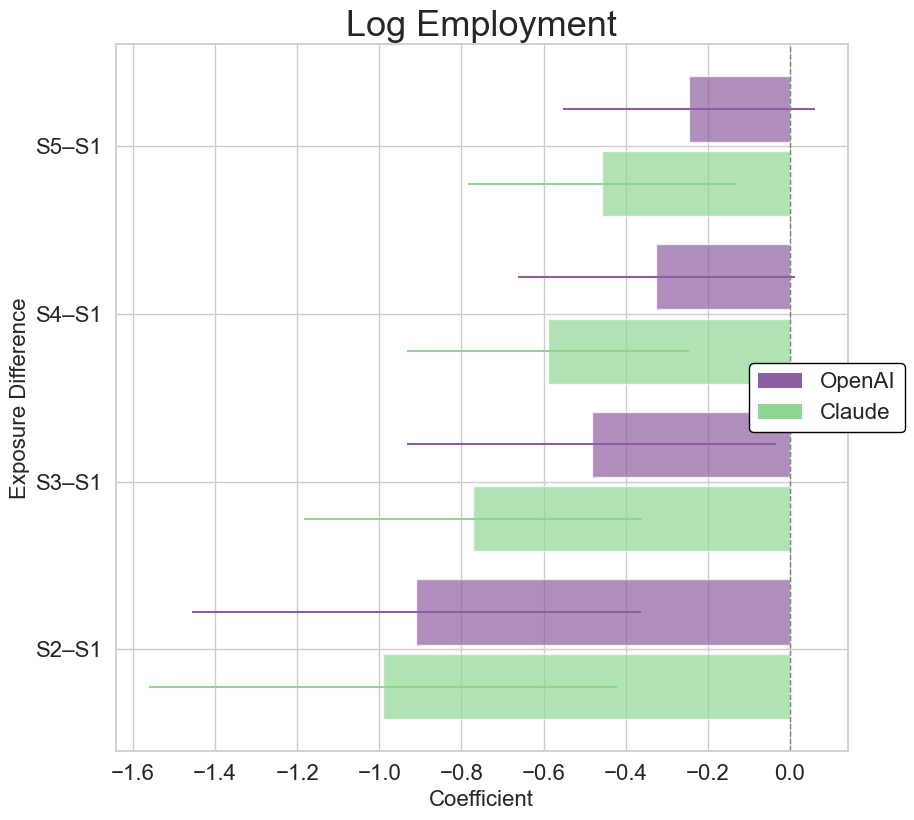

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_unemp_rate_exposure_diffs.png


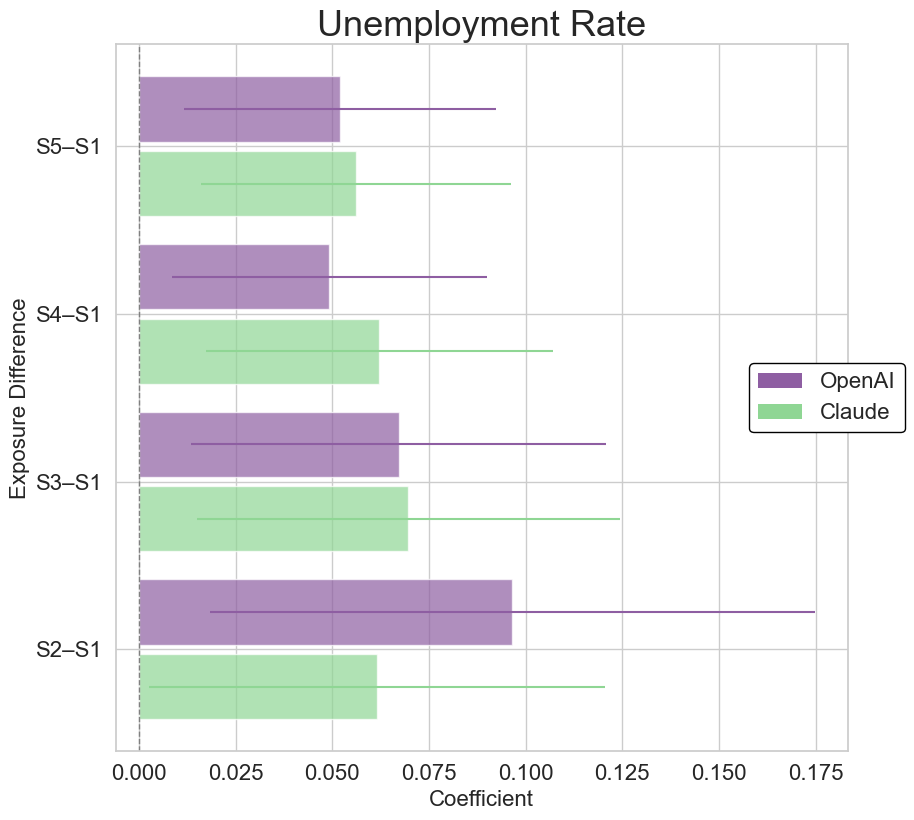

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_ahrswork1_exposure_diffs.png


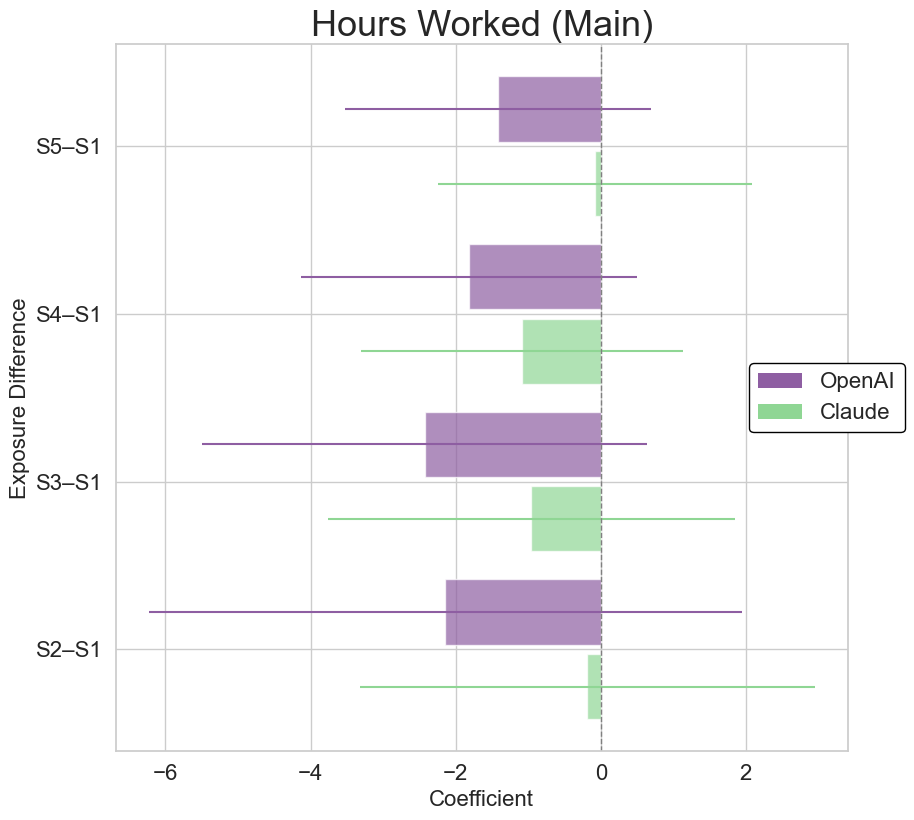

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_ahrswork2_exposure_diffs.png


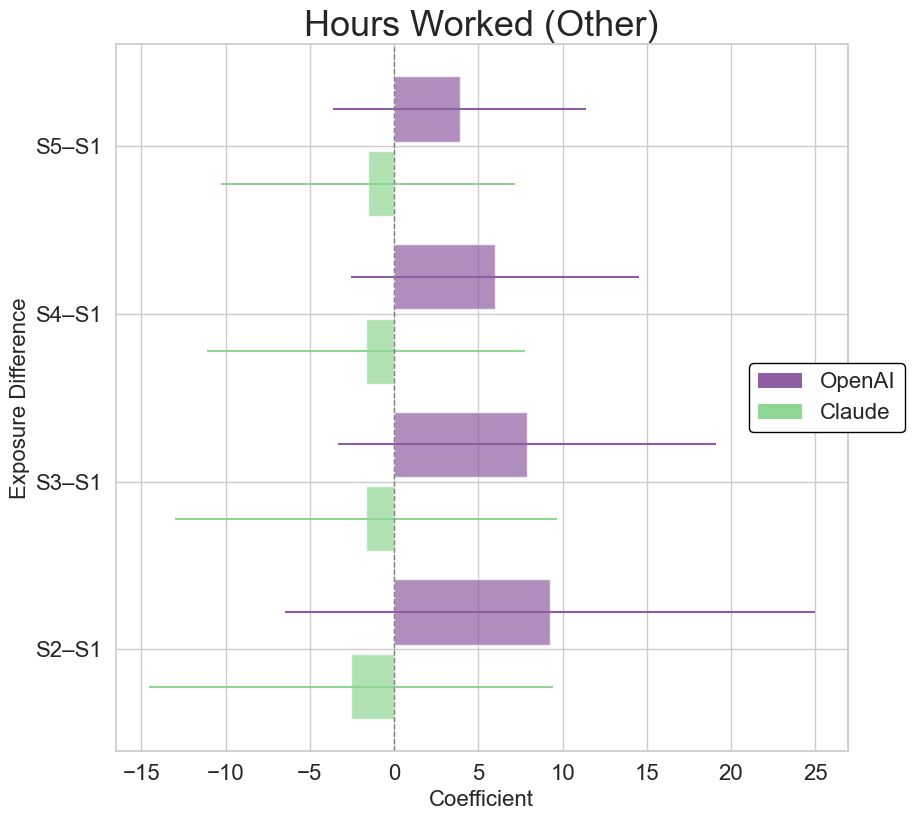

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_ahrsworkt_exposure_diffs.png


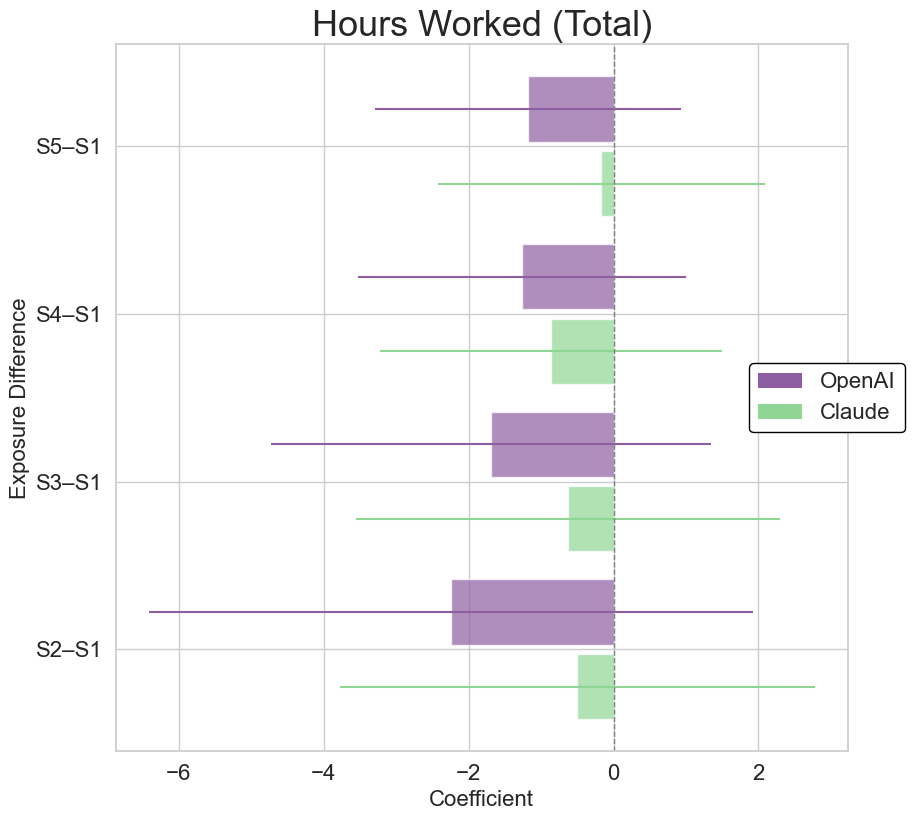

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_other_job_exposure_diffs.png


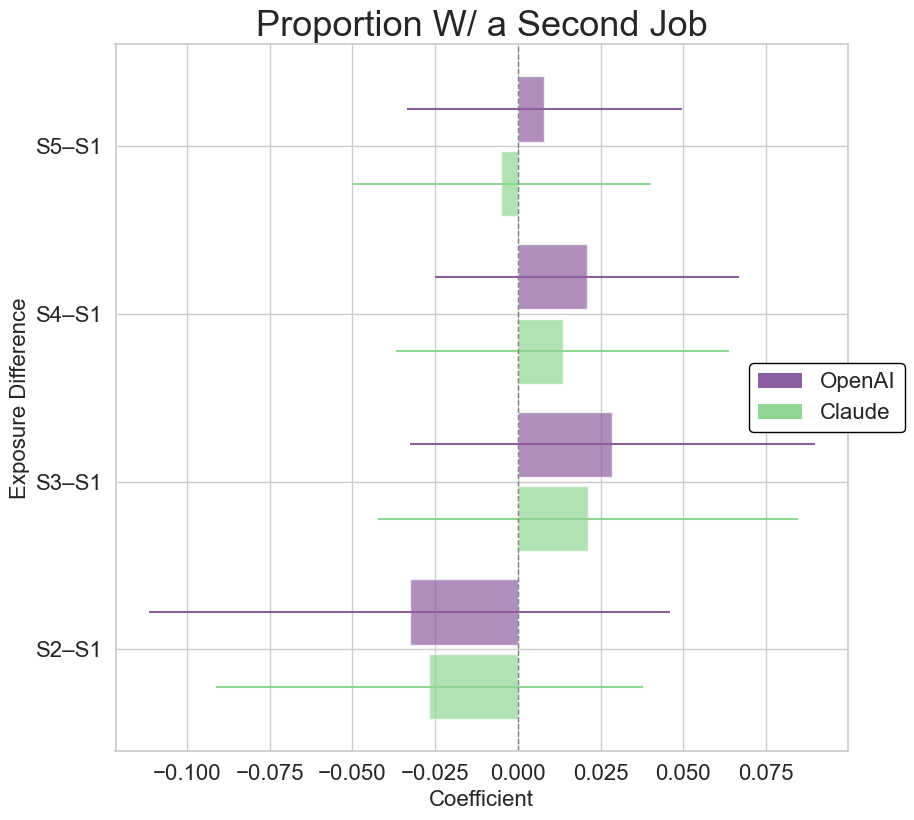

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs/d_fulltime_exposure_diffs.png


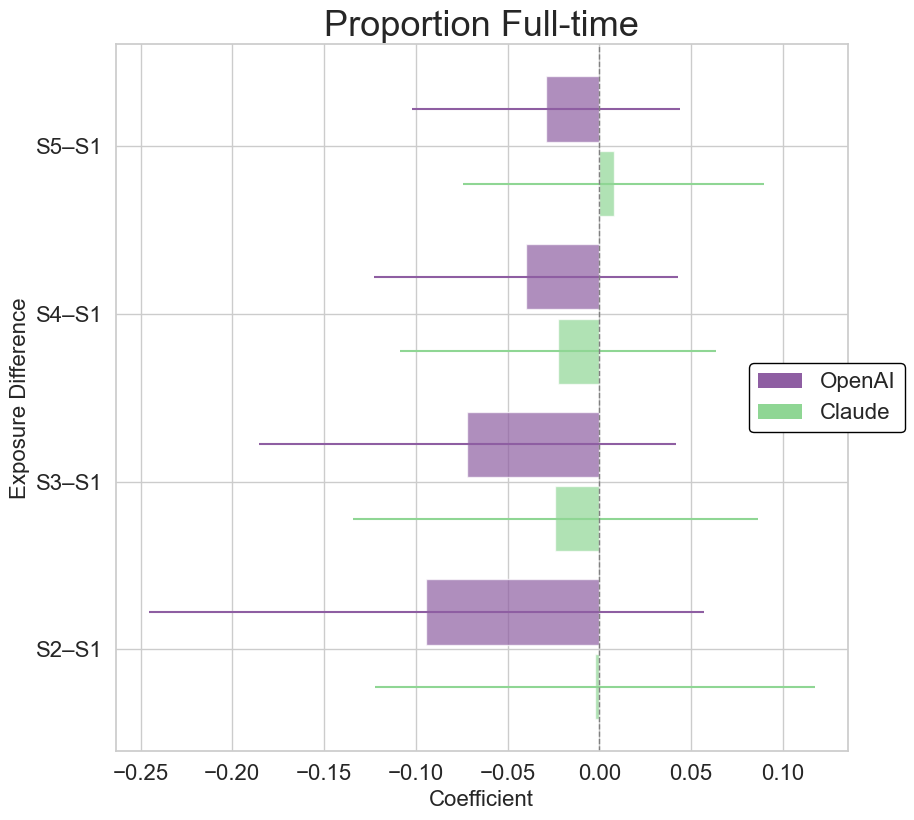

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import os

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_25/openai_exposure_diff_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_25/claude_exposure_diff_estimates.csv")

# === Add model labels and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Normalize exposure diff labels ===
df_all["exposure_diff"] = df_all["exposure_diff"].str.strip().str.upper()

# === Exposure difference order ===
exposure_order = ["S2_S1", "S3_S1", "S4_S1", "S5_S1"]
df_all["exposure_diff"] = pd.Categorical(df_all["exposure_diff"], categories=exposure_order, ordered=True)

# === Clean outcome labels for plotting ===
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Hours Worked (Main)",
    "d_ahrswork2": "Hours Worked (Other)",
    "d_ahrsworkt": "Hours Worked (Total)",
    "d_other_job": "Proportion W/ a Second Job",
    "d_fulltime": "Proportion Full-time"
}

# === Color palette
palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}

# === Output directory
output_dir = "/Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_exposure_diffs"
os.makedirs(output_dir, exist_ok=True)

# === Start plotting
sns.set(style="whitegrid")

for outcome in df_all["outcome"].unique():
    df_sub = df_all[df_all["outcome"] == outcome].copy()
    df_sub = df_sub.sort_values("exposure_diff", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 8))

    spacing = 1.8
    model_offset = {"OpenAI": -0.4, "Claude": 0.4}

    for i, stage in enumerate(exposure_order[::-1]):
        for model in ["OpenAI", "Claude"]:
            row = df_sub[(df_sub["exposure_diff"] == stage) & (df_sub["model"] == model)]
            if row.empty:
                continue
            row = row.iloc[0]
            y = i * spacing + model_offset[model]

            # Confidence interval line
            ax.hlines(
                y=y,
                xmin=row["ci_lower"],
                xmax=row["ci_upper"],
                color=palette[model],
                linewidth=1.5
            )

            # Coefficient bar
            ax.barh(
                y=y,
                width=row["coef"],
                height=0.7,
                color=palette[model],
                alpha=0.7
            )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_yticks([i * spacing for i in range(len(exposure_order))])
    ax.set_yticklabels([s.replace("_", "–") for s in exposure_order[::-1]])
    ax.set_xlabel("Coefficient", fontsize=16)
    ax.set_ylabel("Exposure Difference", fontsize=16)
    ax.set_title(outcome_labels.get(outcome, outcome), fontsize=26)
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    # Legend
    legend_elements = [
        Patch(facecolor=palette["OpenAI"], edgecolor='none', label='OpenAI'),
        Patch(facecolor=palette["Claude"], edgecolor='none', label='Claude'),
    ]
    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(.85, 0.5),
        frameon=True,
        framealpha=1,
        edgecolor='black',
        fontsize=16
    )

    # Set consistent x-axis limits and ensure 0 is included
    x_min = df_sub["ci_lower"].min()
    x_max = df_sub["ci_upper"].max()
    buffer = 0.05 * (x_max - x_min)

    x_lower = min(x_min - buffer, 0) if x_min > 0 else x_min - buffer
    x_upper = max(x_max + buffer, 0) if x_max < 0 else x_max + buffer

    ax.set_xlim(x_lower, x_upper)

    plt.tight_layout(pad=0)
    filename = os.path.join(output_dir, f"{outcome}_exposure_diffs.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {filename}")
    plt.show()


✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_log_emp_P2T_P4T_standardized_exposure_diffs.png


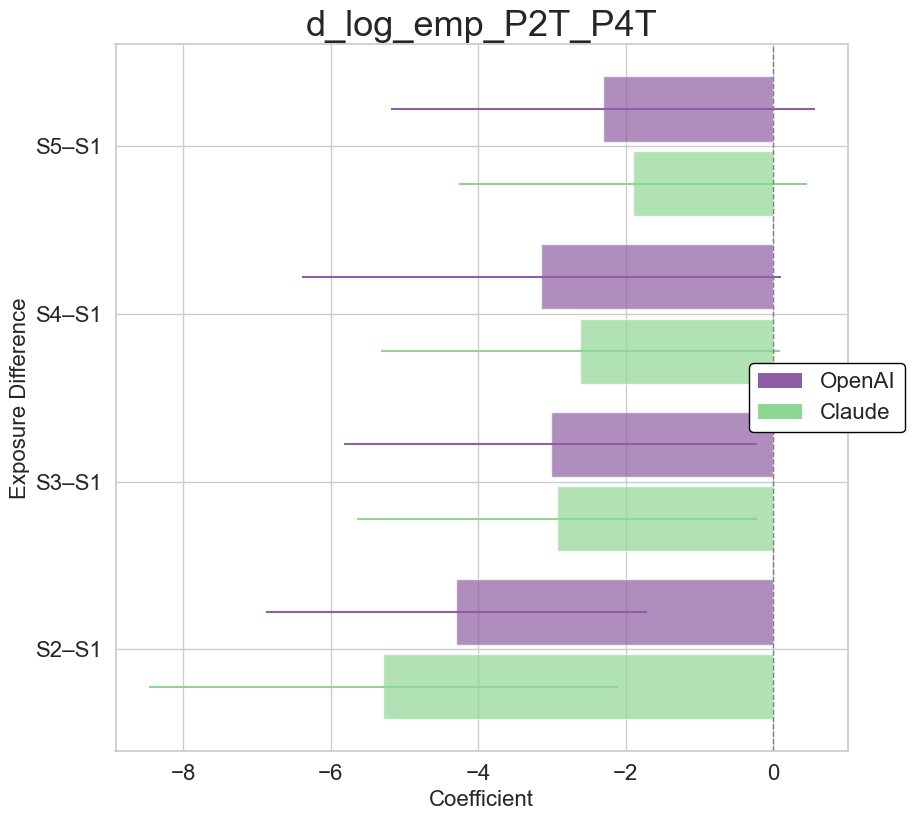

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_unemp_rate_P2T_P4T_standardized_exposure_diffs.png


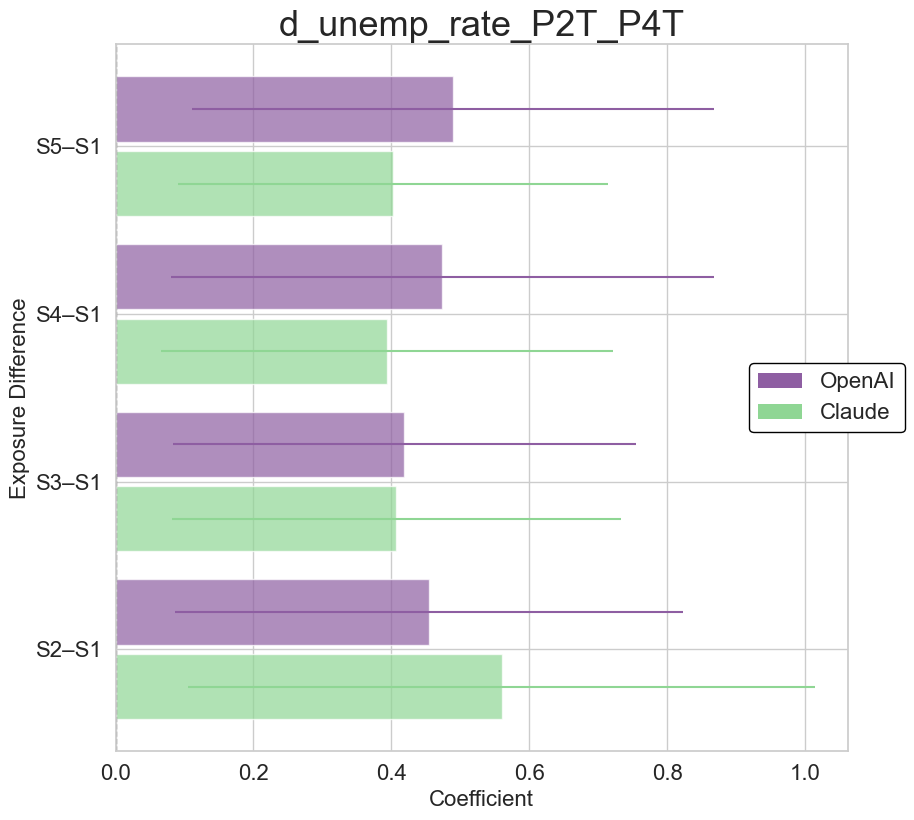

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_ahrswork1_P2T_P4T_standardized_exposure_diffs.png


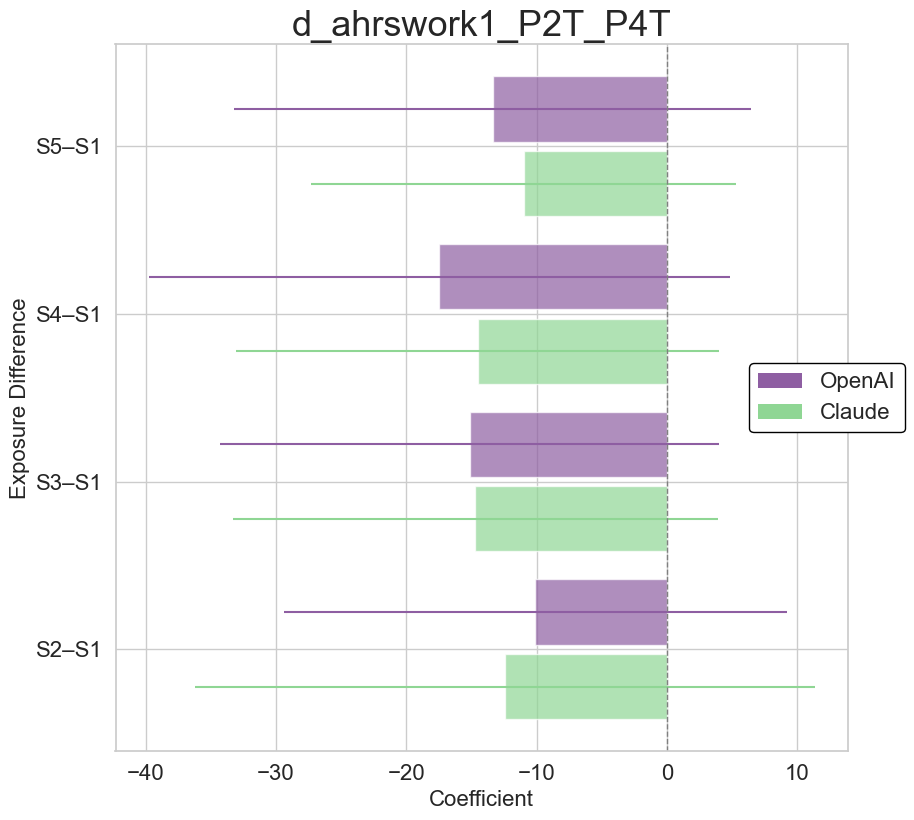

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_ahrswork2_P2T_P4T_standardized_exposure_diffs.png


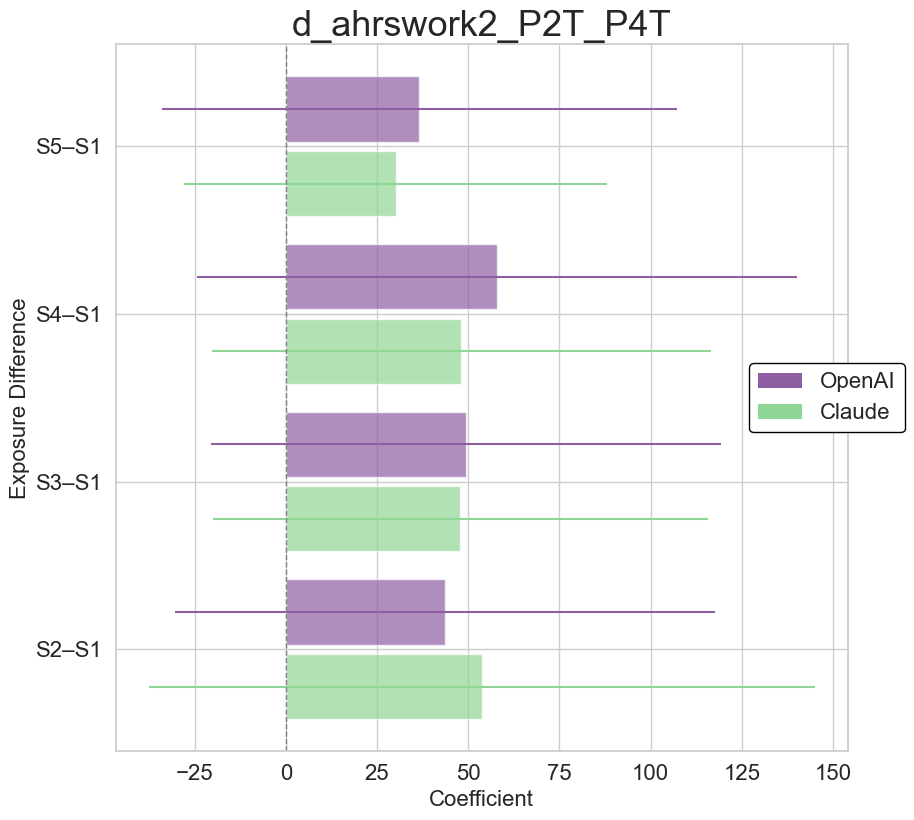

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_ahrsworkt_P2T_P4T_standardized_exposure_diffs.png


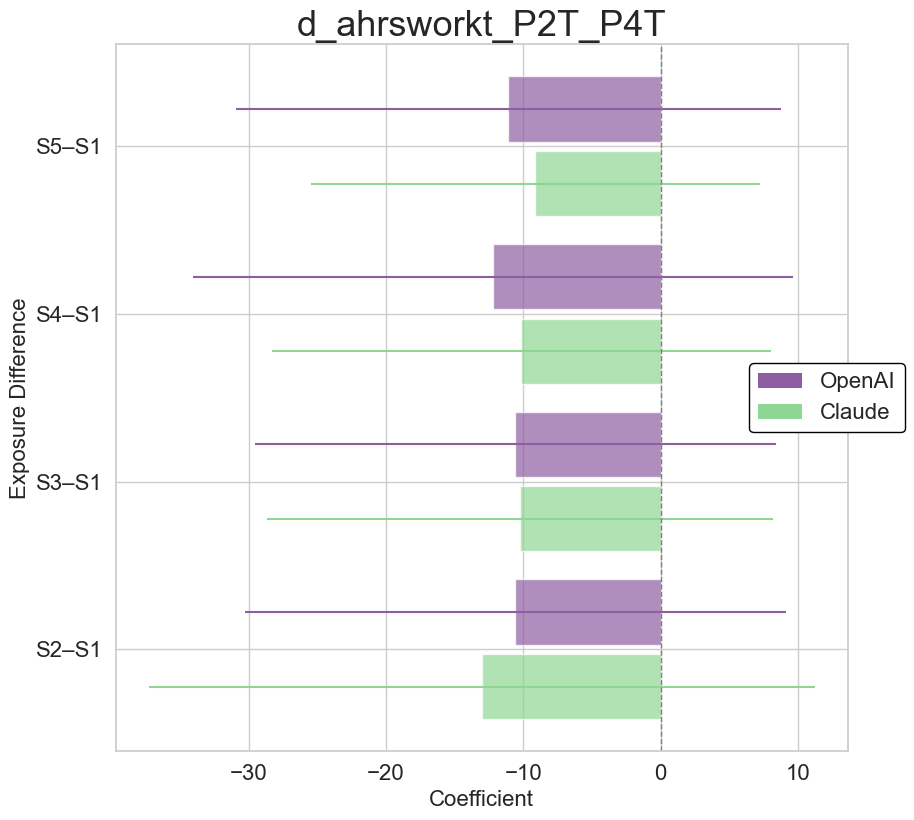

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_other_job_P2T_P4T_standardized_exposure_diffs.png


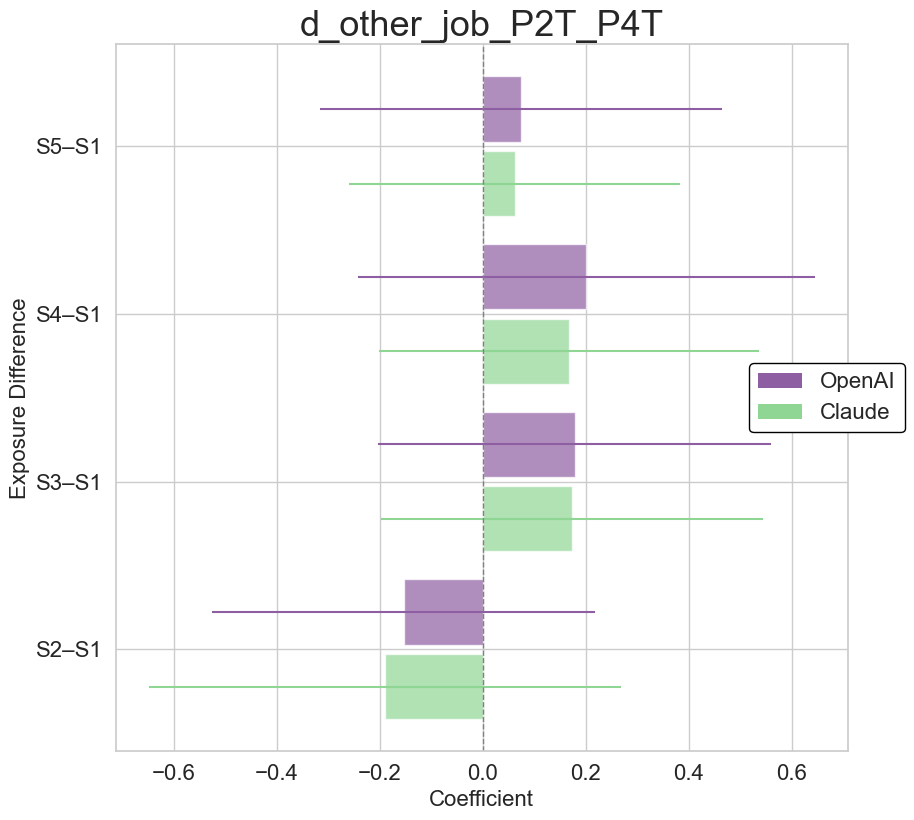

✅ Saved: /Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs/d_fulltime_P2T_P4T_standardized_exposure_diffs.png


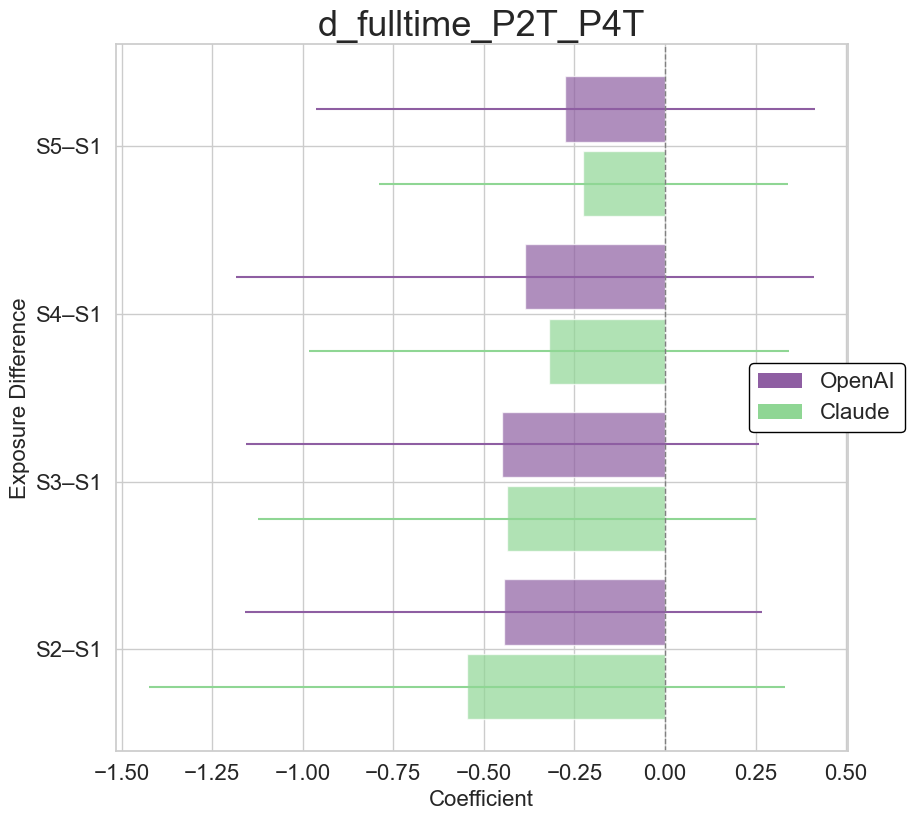

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import os

# === Load your data ===
openai_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_25/standardized_openai_estimates.csv")
claude_df = pd.read_csv("/Users/jdomins2/Desktop/CPS_Work/Output/June/txt/6_25/standardized_claude_estimates.csv")

# === Add model labels and combine ===
openai_df["model"] = "OpenAI"
claude_df["model"] = "Claude"
df_all = pd.concat([openai_df, claude_df], ignore_index=True)

# === Normalize exposure diff labels ===
df_all["exposure_diff"] = df_all["exposure_diff"].str.strip().str.upper()

# === Exposure difference order ===
exposure_order = ["S2_S1", "S3_S1", "S4_S1", "S5_S1"]
df_all["exposure_diff"] = pd.Categorical(df_all["exposure_diff"], categories=exposure_order, ordered=True)

# === Clean outcome labels for plotting ===
outcome_labels = {
    "d_log_emp": "Log Employment",
    "d_unemp_rate": "Unemployment Rate",
    "d_ahrswork1": "Hours Worked (Main)",
    "d_ahrswork2": "Hours Worked (Other)",
    "d_ahrsworkt": "Hours Worked (Total)",
    "d_other_job": "Proportion W/ a Second Job",
    "d_fulltime": "Proportion Full-time"
}

# === Color palette
palette = {"OpenAI": "#8e5ea2", "Claude": "#8fd694"}

# === Output directory
output_dir = "/Users/jdomins2/Desktop/CPS_Work/Output/June/Figures_standardized_exposure_diffs"
os.makedirs(output_dir, exist_ok=True)

# === Start plotting
sns.set(style="whitegrid")

for outcome in df_all["outcome"].unique():
    df_sub = df_all[df_all["outcome"] == outcome].copy()
    df_sub = df_sub.sort_values("exposure_diff", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 8))

    spacing = 1.8
    model_offset = {"OpenAI": -0.4, "Claude": 0.4}

    for i, stage in enumerate(exposure_order[::-1]):
        for model in ["OpenAI", "Claude"]:
            row = df_sub[(df_sub["exposure_diff"] == stage) & (df_sub["model"] == model)]
            if row.empty:
                continue
            row = row.iloc[0]
            y = i * spacing + model_offset[model]

            # Confidence interval line
            ax.hlines(
                y=y,
                xmin=row["ci_lower"],
                xmax=row["ci_upper"],
                color=palette[model],
                linewidth=1.5
            )

            # Coefficient bar
            ax.barh(
                y=y,
                width=row["coef"],
                height=0.7,
                color=palette[model],
                alpha=0.7
            )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_yticks([i * spacing for i in range(len(exposure_order))])
    ax.set_yticklabels([s.replace("_", "–") for s in exposure_order[::-1]])
    ax.set_xlabel("Coefficient", fontsize=16)
    ax.set_ylabel("Exposure Difference", fontsize=16)
    ax.set_title(outcome_labels.get(outcome, outcome), fontsize=26)
    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    # Legend
    legend_elements = [
        Patch(facecolor=palette["OpenAI"], edgecolor='none', label='OpenAI'),
        Patch(facecolor=palette["Claude"], edgecolor='none', label='Claude'),
    ]
    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(.85, 0.5),
        frameon=True,
        framealpha=1,
        edgecolor='black',
        fontsize=16
    )

    # Set consistent x-axis limits and ensure 0 is visible
    x_min = df_sub["ci_lower"].min()
    x_max = df_sub["ci_upper"].max()
    buffer = 0.05 * (x_max - x_min)
    x_lower = min(x_min - buffer, 0)
    x_upper = max(x_max + buffer, 0)
    ax.set_xlim(x_lower, x_upper)

    plt.tight_layout(pad=0)
    filename = os.path.join(output_dir, f"{outcome}_standardized_exposure_diffs.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {filename}")
    plt.show()
